In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import time
import random
import pandas as pd

from sklearn.model_selection import train_test_split , KFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import cross_val_score
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import tensorflow as tf


2025-06-13 09:49:51.294051: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-13 09:49:51.414505: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-13 09:49:51.487083: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749800991.568460  488789 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749800991.589844  488789 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749800991.792792  488789 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
# Load the dataset
raw_data = pd.read_csv('Single_EDFA_Dataset.csv')
raw_data.drop(columns=['measuredTotalPout'], inplace=True)
#raw_data.head(10)

#check for missing or null values
print(raw_data.isnull().sum())
# No missing values found

profileId           0
measuredTotalPin    0
inat152782          0
inat152829          0
inat152876          0
                   ..
outat156495         0
outat156542         0
outat156589         0
outat156636         0
outat156683         0
Length: 170, dtype: int64


In [4]:
def extract_features(data, one_every=1):
    """
    Extracts specific features from the input data based on column filtering.

    Parameters:
    - data (DataFrame): The input data containing multiple columns.
    - one_every (int): The step size for selecting columns from the 'inPot' range. 
                       Defaults to 1 (select all columns).

    Returns:
    - filtered (DataFrame): A filtered DataFrame containing selected columns:
        - The first two columns (head).
        - A subset of columns from 'inPot' based on the step size.
        - All columns from 'outPot'.
    - freq_chan (int): The number of columns selected from 'inPot' after filtering.
    """
    freq_chan = 84
    # Extract features from the data
    head = data.columns[:2]
    inPot = data.columns[2:2+freq_chan]
    outPot = data.columns[-freq_chan:]
    
    inPot = inPot[::one_every]

    filtered_columns = head.tolist() + inPot.tolist() + outPot.tolist()
    filtered = data[filtered_columns]

    freq_chan = len(inPot)

    return filtered, freq_chan


In [5]:
one_every = 1  # Change this to 1 to keep all channels or 2 to keep every other channel ...

data, freq_chan = extract_features(raw_data, one_every=1)

data.head(10)

,profileId,measuredTotalPin,inat152782,inat152829,inat152876,inat152923,inat152970,inat153017,inat153064,inat153111,...,outat156260,outat156307,outat156354,outat156401,outat156448,outat156495,outat156542,outat156589,outat156636,outat156683
0,1002,1.700000,-20.262,-19.152,-19.402,-18.902,-19.052,-19.192,-19.172,-19.092,...,-0.876,-0.896,-0.916,-0.936,-0.966,-0.846,-0.826,-1.136,-1.446,-2.486
1,1002,0.900000,-20.798,-19.688,-20.338,-19.888,-19.898,-19.918,-19.868,-19.838,...,-1.062,-1.142,-1.082,-1.142,-1.192,-1.162,-1.052,-1.212,-1.502,-2.752
2,1002,-0.046481,-21.227,-20.627,-21.417,-20.827,-20.847,-20.797,-20.807,-20.727,...,-1.285,-1.275,-1.295,-1.375,-1.455,-1.385,-1.265,-1.365,-1.515,-2.945
3,1002,-1.500000,-23.007,-22.307,-22.907,-22.247,-22.187,-22.367,-22.217,-22.137,...,-1.599,-1.589,-1.619,-1.759,-1.849,-1.819,-1.749,-1.849,-1.799,-3.219
4,1002,-2.600000,-24.132,-23.302,-23.952,-23.342,-23.122,-23.532,-23.632,-23.752,...,-1.692,-1.842,-1.812,-1.982,-2.152,-2.142,-2.052,-2.052,-2.072,-3.272
5,1002,-3.500000,-25.092,-24.212,-24.732,-24.542,-24.622,-24.582,-24.382,-24.202,...,-1.883,-2.073,-2.193,-2.313,-2.463,-2.493,-2.433,-2.443,-2.353,-3.433
6,1002,-4.500000,-26.080,-25.090,-26.150,-25.560,-25.410,-25.550,-25.580,-25.620,...,-2.104,-2.304,-2.364,-2.654,-2.794,-2.764,-2.674,-2.664,-2.464,-3.644
7,1002,-5.600000,-26.812,-26.222,-27.012,-26.592,-26.492,-26.922,-26.952,-27.142,...,-2.103,-2.333,-2.523,-2.733,-2.993,-3.073,-2.943,-2.843,-2.623,-3.673
8,1002,-6.600000,-28.153,-27.463,-27.823,-27.483,-27.543,-27.843,-28.023,-28.023,...,-2.146,-2.436,-2.626,-2.906,-3.166,-3.276,-3.236,-3.156,-2.836,-3.766
9,10030,1.900000,-24.745,-23.895,-24.565,-24.085,-24.015,-24.265,-24.035,-23.795,...,-1.122,-1.252,-1.442,-1.682,-1.922,-1.942,-1.872,-2.092,-2.512,-3.932


In [6]:
def train_NN(X_tr, y_tr, activ, neur, lyrs):
    """
    Trains a neural network using K-Fold cross-validation and evaluates its performance.

    Parameters:
    - X_tr (array-like): Training features.
    - y_tr (array-like): Training target values.
    - activ (str): Activation function to use in the hidden layers (e.g., 'relu', 'sigmoid').
    - neur (int): Number of neurons per hidden layer.
    - lyrs (int): Number of hidden layers in the neural network.

    Returns:
    - model (Sequential): The trained neural network model.
    - training_time (float): Total time taken for training the model (5 times).
    - avg_scores (list): Average performance metrics across folds:
        - Mean Squared Error (MSE).
        - Mean Absolute Error (MAE).
        - R-squared (R2).
    """
    print('Training a NN...')
    print(f'Activation function: {activ}, Neurons per layer: {neur}, Number of layers: {lyrs}')

    # Kfold k = 5
    kf = KFold(n_splits=5, shuffle=True, random_state=42) 
    
    mae = []
    mse = []
    r2 = []
    start_time = time.time()
    for train_index, test_index in kf.split(X_tr, y_tr):
        X_train_fold, X_test_fold = X_tr[train_index], X_tr[test_index]
        y_train_fold, y_test_fold = y_tr.iloc[train_index], y_tr.iloc[test_index]

        # Create a neural network regressor
        model = Sequential()
        model.add(Input(shape=(X_train_fold.shape[1],)))
        # Add hidden layers
        for _ in range(lyrs):
            model.add(Dense(neur, activation=activ))        
        # Add the output layer
        model.add(Dense(84))  # 84 outputs, one per channel
        model.compile(optimizer='adam', loss='mse', metrics=['mse', 'mae', 'r2_score'])
        print(X_train_fold.shape, y_train_fold.shape)
        model.fit(X_train_fold, y_train_fold, epochs=15, batch_size=32, validation_split=0.2, verbose=0)
    
        scores = model.evaluate(X_test_fold, y_test_fold, verbose=0)
        mse.append(scores[1])
        mae.append(scores[2])
        r2.append(scores[3])
        print(f'Fold Number {len(mse)}: MSE = {mse[-1]:.4f}, MAE = {mae[-1]:.4f}, R2 = {r2[-1]:.4f}')

    avg_mse = np.mean(mse)
    avg_mae = np.mean(mae)
    avg_r2 = np.mean(r2)
    
    print(f'Average MSE: {avg_mse:.4f}, Average MAE: {avg_mae:.4f}, Average R2: {avg_r2:.4f}')

    avg_scores = [avg_mse, avg_mae, avg_r2]

    training_time = time.time() - start_time # Note: this is the time for 5 folds

    #plt.savefig('Results/training_loss_curve_'+solv_name+'.png')
    
    return model, training_time, avg_scores



In [7]:
activation = ['relu', 'tanh', 'sigmoid', 'linear'] #
neurons = [16, 32, 64, 128]
layers = [1, 2, 3]

X = data[data.columns[1:2+freq_chan]]
y = data[data.columns[-84:]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize t.tolist()he data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [7]:
display(X_train)
print(freq_chan)

,measuredTotalPin,inat152782,inat152829,inat152876,inat152923,inat152970,inat153017,inat153064,inat153111,inat153158,...,inat156260,inat156307,inat156354,inat156401,inat156448,inat156495,inat156542,inat156589,inat156636,inat156683
10652,-3.5,-21.636,-21.656,-21.536,-21.156,-20.796,-20.776,-20.736,-20.856,-20.726,...,-25.666,-25.876,-25.946,-26.456,-26.606,-26.746,-26.886,-27.126,-27.046,-26.836
10003,-2.8,-28.584,-28.454,-28.104,-28.324,-27.824,-28.404,-28.304,-28.784,-28.284,...,-18.594,-18.414,-17.984,-17.354,-16.874,-16.584,-16.544,-16.794,-17.054,-17.904
4153,-2.5,-23.141,-22.591,-23.041,-22.411,-22.411,-22.441,-22.331,-22.281,-22.471,...,-21.521,-21.431,-21.381,-21.271,-21.181,-21.011,-20.791,-20.621,-20.271,-20.381
11427,-4.7,-23.093,-22.753,-22.723,-22.703,-22.053,-22.493,-22.233,-22.623,-22.513,...,-23.803,-23.863,-23.633,-23.513,-23.433,-23.113,-22.833,-22.573,-22.203,-22.413
5903,-6.4,-34.301,-33.451,-33.401,-32.661,-32.631,-34.161,-34.211,-34.131,-35.041,...,-22.771,-22.601,-22.291,-22.031,-21.541,-20.701,-19.991,-19.731,-19.641,-20.391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-5.3,-24.203,-23.973,-23.783,-23.943,-23.893,-24.123,-23.853,-23.943,-23.903,...,-26.113,-26.473,-26.583,-26.893,-27.023,-27.093,-27.063,-27.093,-26.853,-26.643
11964,-1.5,-21.393,-21.203,-21.773,-21.083,-21.153,-21.093,-21.193,-21.203,-21.313,...,-20.373,-20.253,-20.063,-19.973,-19.873,-19.723,-19.423,-19.293,-18.933,-19.233
5390,-6.0,-27.165,-26.015,-26.235,-25.245,-25.005,-24.735,-24.415,-23.955,-23.715,...,-26.315,-26.275,-26.445,-26.755,-26.995,-27.325,-27.545,-27.775,-27.645,-27.255
860,-3.6,-23.242,-22.612,-23.122,-22.452,-22.392,-22.382,-22.312,-22.422,-22.612,...,-23.352,-23.382,-23.342,-23.352,-23.332,-23.192,-22.982,-22.892,-22.532,-22.202


84


In [ ]:
# ------------- DON'T RUN THIS AGAIN -------------
# RESULTS ARE IN hp_opt_metrics/parameters_one_every_X.csv

# Better to run this in smaller chunks to avoid long processing times... and to blow my pc up :)
for one_every in [1, 2, 3, 5, 10]: #1, 2, 3, 5, 10 
    with open(f'hp_opt_metrics/parameters_one_every_{one_every}.csv', 'w') as f:
        f.write(f"Activation,Neurons,Layers,MSE,MAE,R2,Training Time\n")
    
    # Prepare the data for the current one_every
    print(f'Processing with one_every={one_every}...')
    X_temp, freq_chan = extract_features(raw_data, one_every=one_every)
    X = X_temp[X_temp.columns[1:2+freq_chan]] 
    y = X_temp[X_temp.columns[-84:]]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
    # Normalize the data
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)

    # Loop through hyperparameters and train the model
    for activ in activation:
        for neur in neurons:
            for lyrs in layers:
                model, training_time, metrics = train_NN(X_train_std, y_train, activ, neur, lyrs)
                with open(f'hp_opt_metrics/parameters_one_every_{one_every}.csv', 'a') as f:
                    f.write(f"{activ},{neur},{lyrs},{metrics[0]},{metrics[1]},{metrics[2]},{training_time}\n")

Processing with one_every=10...
(13197, 10) (3300, 10) (13197, 84) (3300, 84)
Training a NN...
Activation function: relu, Neurons per layer: 16, Number of layers: 1
(10557, 10) (10557, 84)
Fold Number 1: MSE = 0.2467, MAE = 0.3370, R2 = 0.9391
(10557, 10) (10557, 84)
Fold Number 2: MSE = 0.2733, MAE = 0.3484, R2 = 0.9371
(10558, 10) (10558, 84)
Fold Number 3: MSE = 0.2577, MAE = 0.3486, R2 = 0.9377
(10558, 10) (10558, 84)
Fold Number 4: MSE = 0.2584, MAE = 0.3475, R2 = 0.9336
(10558, 10) (10558, 84)
Fold Number 5: MSE = 0.2749, MAE = 0.3591, R2 = 0.9353
Average MSE: 0.2622, Average MAE: 0.3481, Average R2: 0.9366
Training a NN...
Activation function: relu, Neurons per layer: 16, Number of layers: 2
(10557, 10) (10557, 84)
Fold Number 1: MSE = 0.1943, MAE = 0.2980, R2 = 0.9510
(10557, 10) (10557, 84)
Fold Number 2: MSE = 0.2095, MAE = 0.3044, R2 = 0.9446
(10558, 10) (10558, 84)
Fold Number 3: MSE = 0.2308, MAE = 0.3205, R2 = 0.9437
(10558, 10) (10558, 84)
Fold Number 4: MSE = 0.2080, MA

In [8]:
best_parameters = {}  # Dictionary to store the best parameters for each one_every value

for one_every in [1, 2, 3, 5, 10]:
    best_parameters[f'one_every_{one_every}'] = {'activation': 'Topo gigio',
                                                    'neurons': -1,
                                                    'layers': -1,
                                                    'mse': 999,
                                                    'mae': 999,
                                                    'r2': -999,
                                                    'training_time': 0
                                                    }               
    for line in open(f'hp_opt_metrics/parameters_one_every_{one_every}.csv').readlines()[1:]:
        activ, neur, lyrs, mse, mae, r2, training_time = line.strip().split(',')
        neur = int(neur)
        lyrs = int(lyrs)
        mse = float(mse)
        mae = float(mae)
        r2 = float(r2)
        training_time = float(training_time)

        # Check if the current parameters yield a better score
        if mse < best_parameters[f'one_every_{one_every}']['mse']:
            best_parameters[f'one_every_{one_every}']['activation'] = activ
            best_parameters[f'one_every_{one_every}']['neurons'] = neur
            best_parameters[f'one_every_{one_every}']['layers'] = lyrs
            best_parameters[f'one_every_{one_every}']['mse'] = mse
            best_parameters[f'one_every_{one_every}']['mae'] = mae
            best_parameters[f'one_every_{one_every}']['r2'] = r2
            best_parameters[f'one_every_{one_every}']['training_time'] = training_time

In [9]:
best_parameters

{'one_every_1': {'activation': 'relu',
  'neurons': 128,
  'layers': 2,
  'mse': 0.04199244976043701,
  'mae': 0.14574085175991058,
  'r2': 0.9902734756469727,
  'training_time': 48.48757553100586},
 'one_every_2': {'activation': 'relu',
  'neurons': 128,
  'layers': 2,
  'mse': 0.04206980913877487,
  'mae': 0.14629900455474854,
  'r2': 0.9901654839515686,
  'training_time': 49.581499338150024},
 'one_every_3': {'activation': 'relu',
  'neurons': 128,
  'layers': 2,
  'mse': 0.042020737379789355,
  'mae': 0.144916632771492,
  'r2': 0.9900793552398681,
  'training_time': 49.274423360824585},
 'one_every_5': {'activation': 'relu',
  'neurons': 128,
  'layers': 2,
  'mse': 0.04840897172689438,
  'mae': 0.15454070568084716,
  'r2': 0.9888771414756775,
  'training_time': 48.81384992599487},
 'one_every_10': {'activation': 'relu',
  'neurons': 128,
  'layers': 3,
  'mse': 0.07828130573034286,
  'mae': 0.19334785044193267,
  'r2': 0.9823666930198669,
  'training_time': 48.9149866104126}}

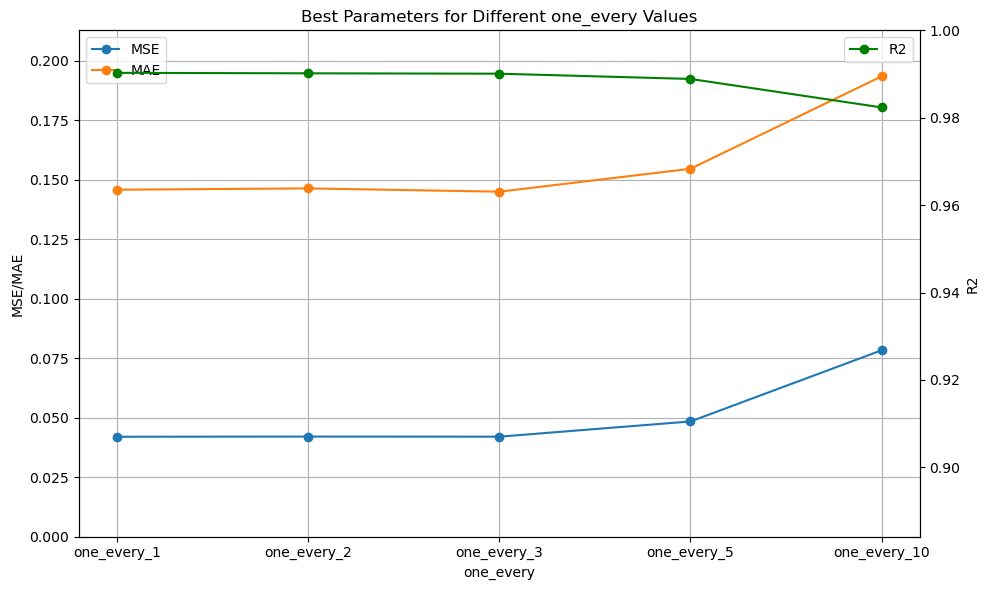

In [9]:
# Plot best parameters
fig, ax = plt.subplots(figsize=(10, 6))
one_every_values = list(best_parameters.keys())

mse_values = [best_parameters[oe]['mse'] for oe in one_every_values]
ax.plot(one_every_values, mse_values, marker='o', label='MSE')
mae_values = [best_parameters[oe]['mae'] for oe in one_every_values]
ax.plot(one_every_values, mae_values, marker='o', label='MAE')
r2_values = [best_parameters[oe]['r2'] for oe in one_every_values]

# 2 different y axes (1 for mse/mae and 1 for r2)
ax.set_xlabel('one_every')
ax.set_ylabel('MSE/MAE')
ax.set_ylim(0, max(max(mse_values), max(mae_values)) * 1.1)
ax2 = ax.twinx()
ax2.set_ylabel('R2')
ax2.set_ylim(min(r2_values) * 0.9, 1.0)  # R2 is between -1 and 1, so we set limits accordingly
ax2.plot(one_every_values, r2_values, marker='o', color='green', label='R2')
ax.set_title('Best Parameters for Different one_every Values')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.xticks(rotation=45)
ax.grid()
plt.tight_layout()
# Save the best parameters to a CSV file
    

Best parameters for one_every=1: {'activation': 'relu', 'neurons': 128, 'layers': 2, 'mse': 0.04199244976043701, 'mae': 0.14574085175991058, 'r2': 0.9902734756469727, 'training_time': 48.48757553100586}
Training a NN...
Activation function: relu, Neurons per layer: 128, Number of layers: 2
(10557, 85) (10557, 84)


2025-06-13 09:50:09.344767: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Fold Number 1: MSE = 0.0382, MAE = 0.1396, R2 = 0.9907
(10557, 85) (10557, 84)
Fold Number 2: MSE = 0.0392, MAE = 0.1399, R2 = 0.9905
(10558, 85) (10558, 84)
Fold Number 3: MSE = 0.0443, MAE = 0.1500, R2 = 0.9894
(10558, 85) (10558, 84)
Fold Number 4: MSE = 0.0436, MAE = 0.1510, R2 = 0.9900
(10558, 85) (10558, 84)
Fold Number 5: MSE = 0.0397, MAE = 0.1413, R2 = 0.9913
Average MSE: 0.0410, Average MAE: 0.1443, Average R2: 0.9904
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


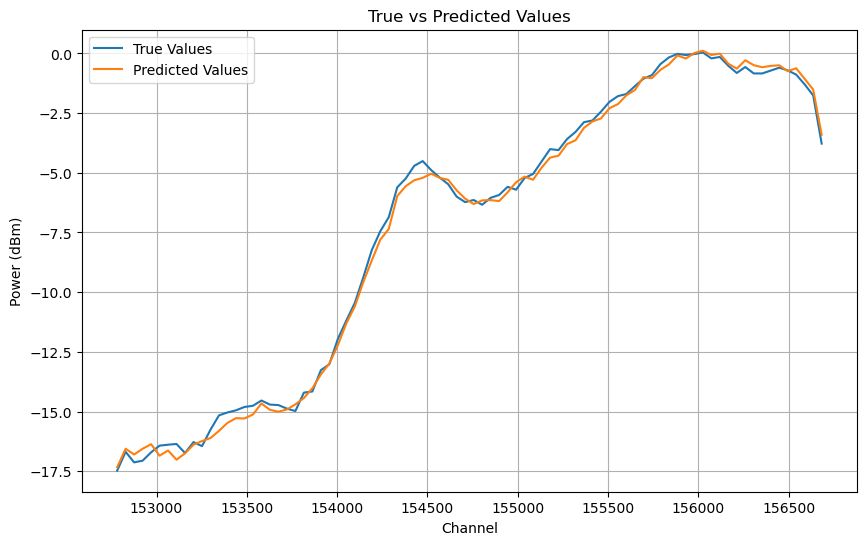

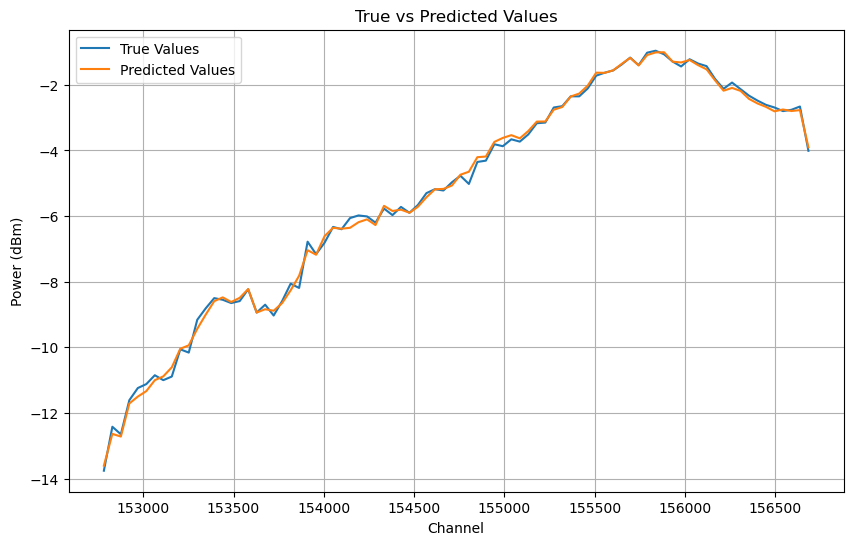

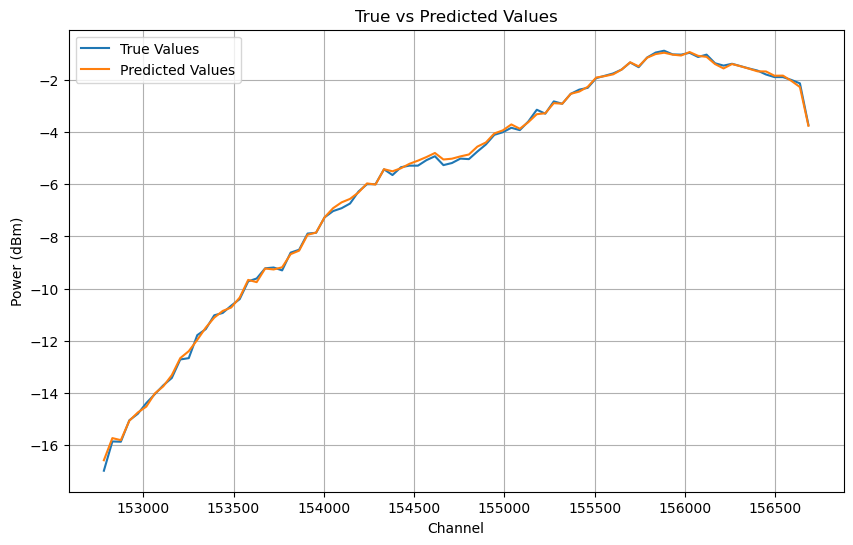

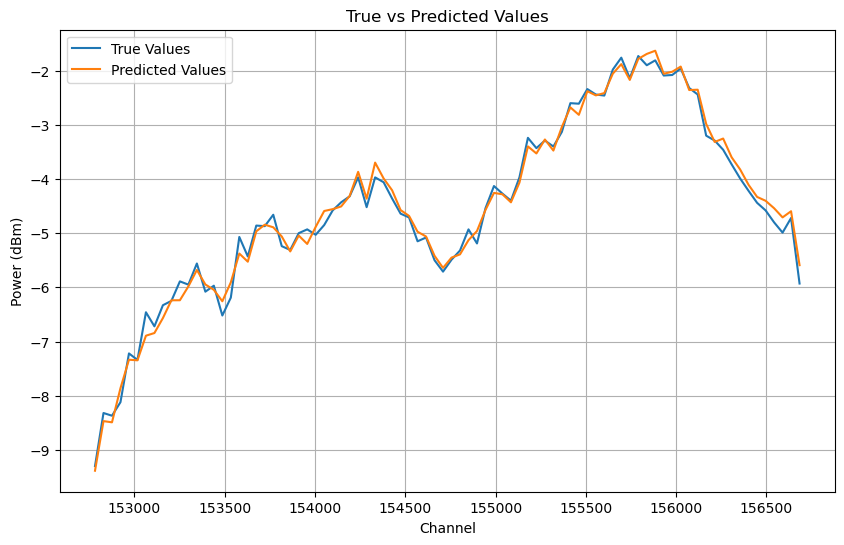

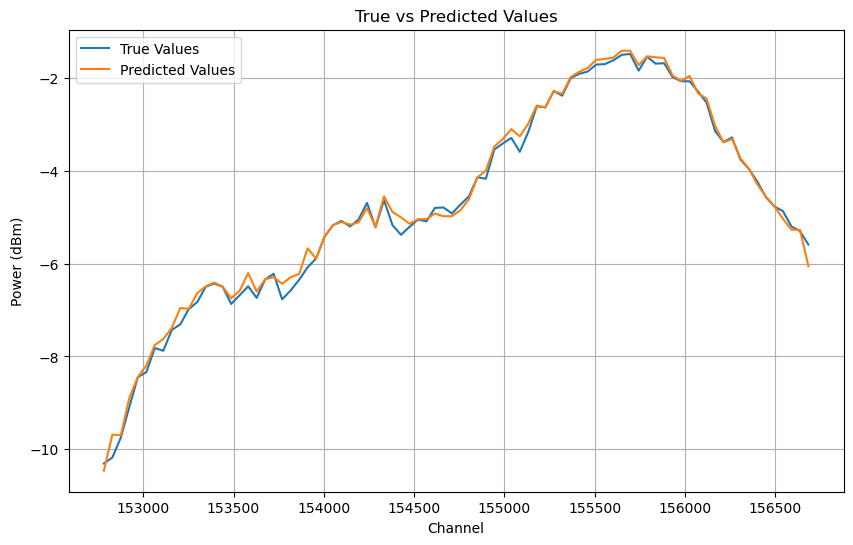

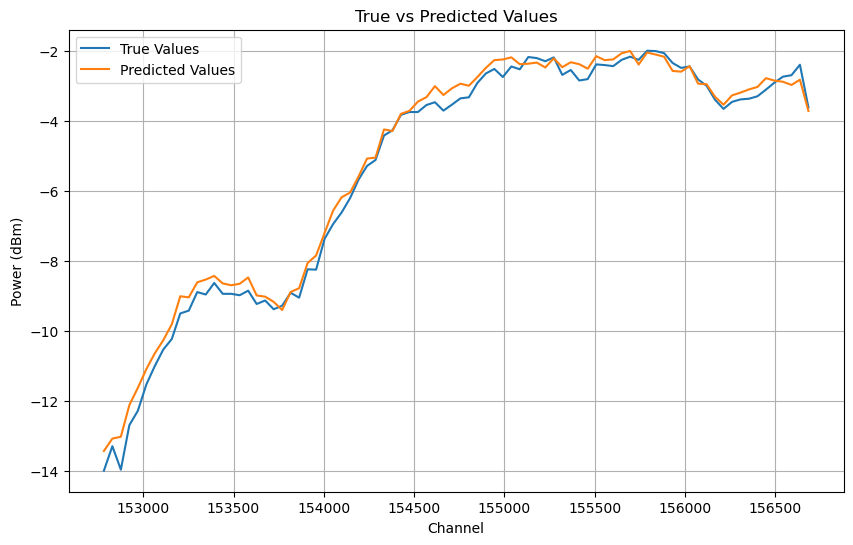

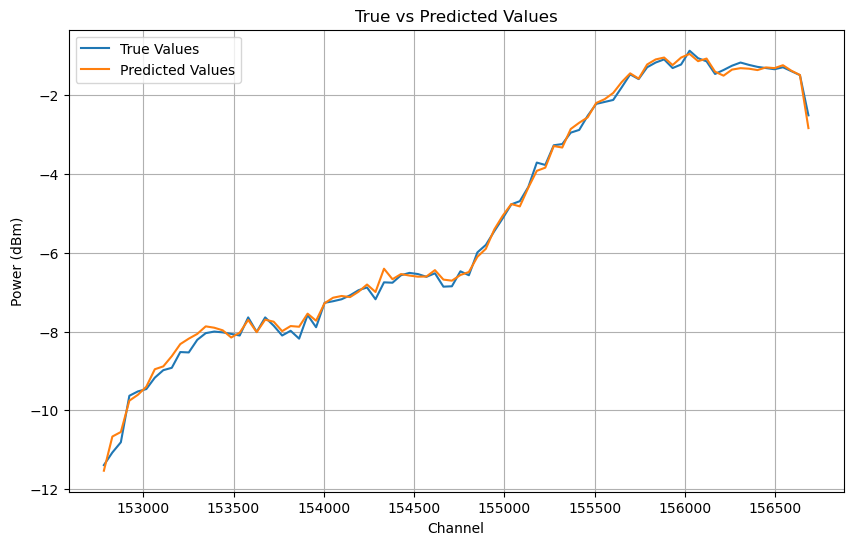

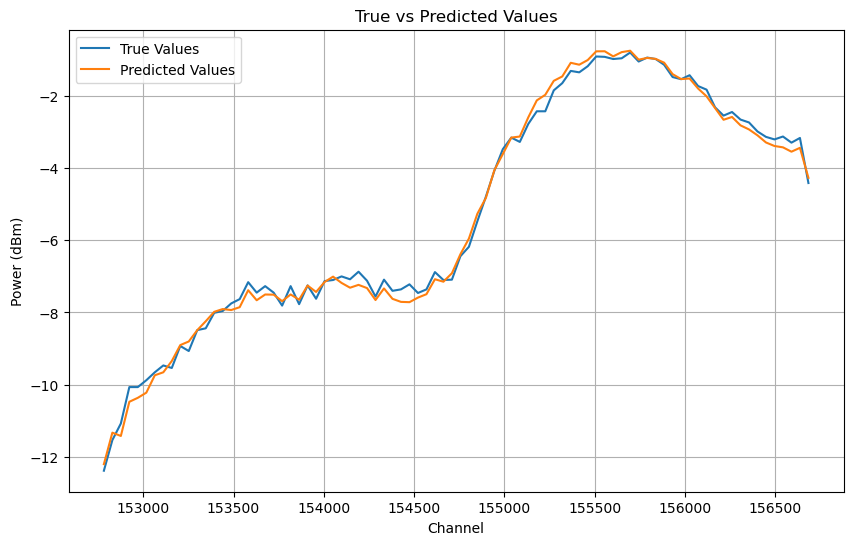

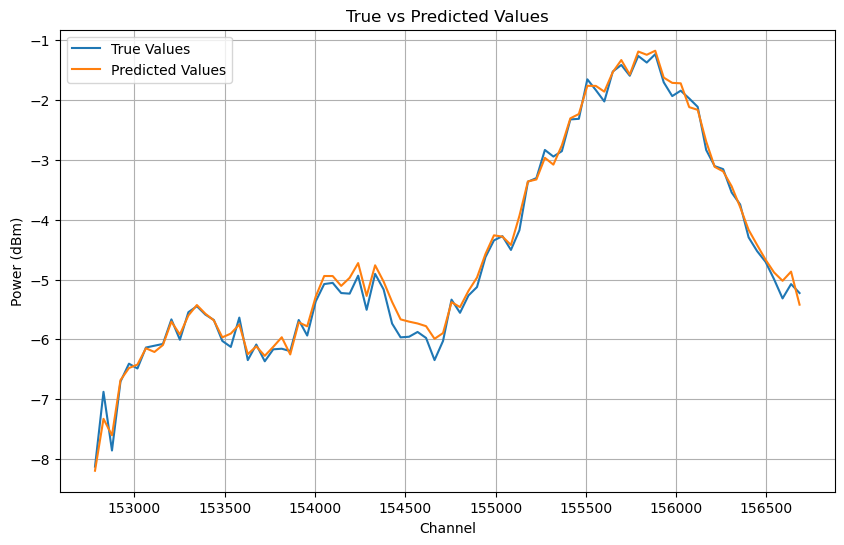

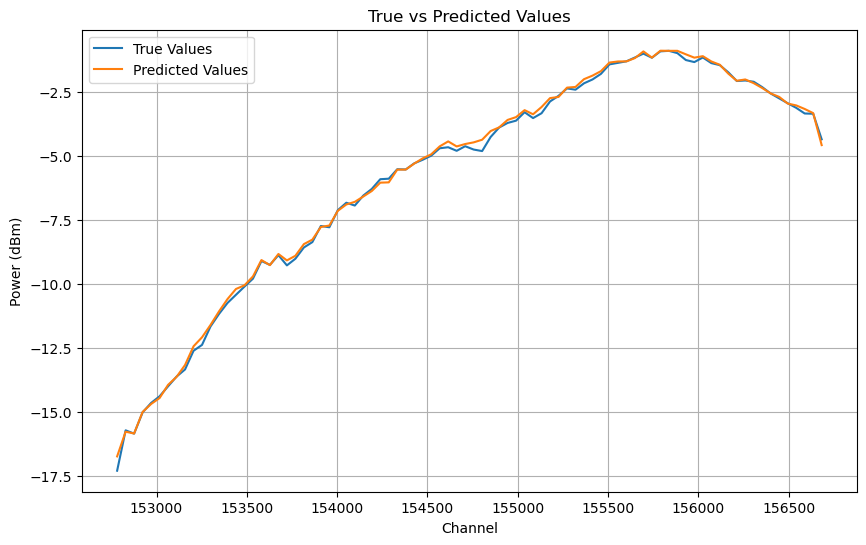

In [10]:
min_freq = 152782
max_freq = 156683

freqs = np.linspace(min_freq, max_freq, 84)

# Use the best parameters found
best_one_every = 1  # Change this to the best one_every found
best_params = best_parameters[f'one_every_{best_one_every}']
print(f'Best parameters for one_every={best_one_every}: {best_params}')

X_temp, freq_chan = extract_features(raw_data, one_every=best_one_every)
X = X_temp[X_temp.columns[1:2+freq_chan]]
y = X_temp[X_temp.columns[-84:]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

model, training_time, metrics = train_NN(X_train_std, y_train, 
                                        best_params['activation'], 
                                        best_params['neurons'], 
                                        best_params['layers'])

# Make predictions
y_pred = model.predict(X_test_std)
# Convert predictions to DataFrame for easier plotting
y_pred = pd.DataFrame(y_pred, columns=y_test.columns)
for idx in range(10): #y_test.shape[0]X_tr[train_index], X_tr[test_index]
    #Plot
    plt.figure(figsize=(10, 6))
    plt.plot(freqs, y_test.iloc[idx], label='True Values')
    plt.plot(freqs, y_pred.iloc[idx], label='Predicted Values')
    plt.title('True vs Predicted Values')
    plt.xlabel('Channel')
    plt.ylabel('Power (dBm)')
    plt.legend()
    plt.grid()
    plt.show()

In [27]:
display(y)
print(freq_chan)

,outat152782,outat152829,outat152876,outat152923,outat152970,outat153017,outat153064,outat153111,outat153158,outat153205,...,outat156260,outat156307,outat156354,outat156401,outat156448,outat156495,outat156542,outat156589,outat156636,outat156683
0,-18.736,-17.176,-16.996,-16.116,-15.856,-15.616,-15.196,-14.746,-14.536,-13.786,...,-0.876,-0.896,-0.916,-0.936,-0.966,-0.846,-0.826,-1.136,-1.446,-2.486
1,-17.462,-15.902,-16.152,-15.302,-14.902,-14.552,-14.142,-13.752,-13.432,-12.792,...,-1.062,-1.142,-1.082,-1.142,-1.192,-1.162,-1.052,-1.212,-1.502,-2.752
2,-15.955,-14.875,-15.225,-14.225,-13.875,-13.475,-13.095,-12.735,-12.505,-11.625,...,-1.285,-1.275,-1.295,-1.375,-1.455,-1.385,-1.265,-1.365,-1.515,-2.945
3,-14.989,-13.799,-13.949,-12.859,-12.579,-12.359,-11.799,-11.439,-11.449,-10.709,...,-1.599,-1.589,-1.619,-1.759,-1.849,-1.819,-1.749,-1.849,-1.799,-3.219
4,-14.292,-12.942,-13.162,-12.062,-11.612,-11.682,-11.432,-11.282,-11.222,-10.582,...,-1.692,-1.842,-1.812,-1.982,-2.152,-2.142,-2.052,-2.052,-2.072,-3.272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16492,-11.438,-10.788,-11.028,-9.968,-9.728,-9.418,-8.978,-8.688,-8.548,-7.968,...,-3.938,-4.078,-4.128,-4.208,-4.258,-4.028,-4.018,-4.198,-4.138,-5.968
16493,-11.105,-10.165,-10.365,-9.455,-9.005,-9.335,-8.995,-8.765,-8.675,-8.085,...,-4.145,-4.345,-4.385,-4.565,-4.505,-4.465,-4.335,-4.535,-4.565,-6.455
16494,-10.572,-9.582,-9.842,-9.172,-8.942,-8.572,-8.072,-7.802,-7.682,-7.132,...,-4.142,-4.492,-4.612,-4.792,-4.772,-4.762,-4.832,-4.862,-4.772,-6.812
16495,-9.912,-8.852,-9.602,-8.412,-8.132,-7.962,-7.642,-7.362,-7.142,-6.522,...,-4.382,-4.802,-4.802,-5.152,-5.152,-5.092,-5.142,-5.292,-5.182,-7.162


84


535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


PermutationExplainer explainer:   5%|▌         | 5/100 [00:00<?, ?it/s]

535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step


PermutationExplainer explainer:   7%|▋         | 7/100 [00:11<01:21,  1.14it/s]

535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [02:49<00:01,  1.72s/it]

535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step


PermutationExplainer explainer: 100%|██████████| 100/100 [02:50<00:00,  1.70s/it]

535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step


PermutationExplainer explainer: 101it [02:52,  1.80s/it]                         


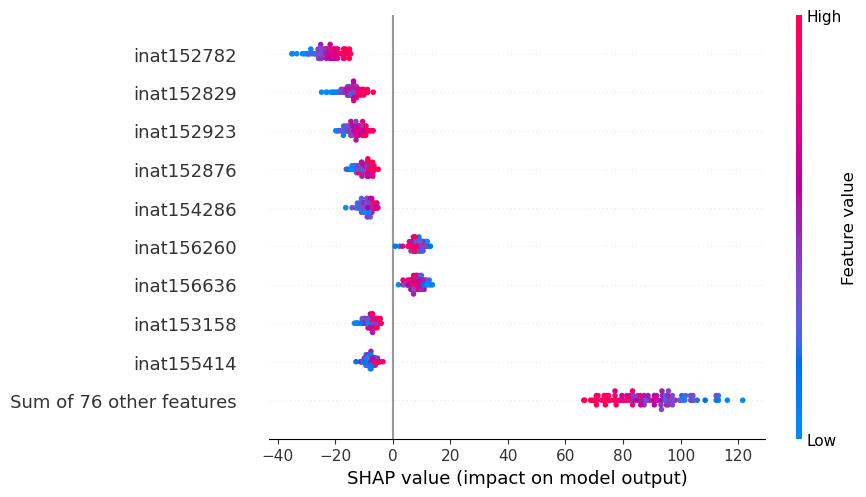

In [17]:
import shap

# Prepare your background and test datasets
background = X_train_std[:1000]
X_sample = X_test[:100]

# Define a prediction function
def predict_fn(data):
    return model.predict(data) 

# Create the SHAP explainer with permutation algorithm 
# This is a model agnostic explainer
explainer = shap.Explainer(predict_fn, background, algorithm='permutation')

# Compute SHAP values
shap_values = explainer(X_sample)

# Visualize the SHAP values for the first output
shap.plots.beeswarm(shap_values[:, :, 0])

In [ ]:
# DON'T RUN THIS AGAIN

# Save SHAP values for each channel
if not os.path.exists('shap_swarms'):
    os.makedirs('shap_swarms')
for i in range(84):
    shap.summary_plot(shap_values[:, :, i], sort=False, max_display=84, show=False)
    plt.title(f'SHAP Values for Channel {y.columns[i]}')
    #plt.savefig(f'shap_swarms/SHAP_Values_Channel_{y.columns[i]}.png')
    plt.close()

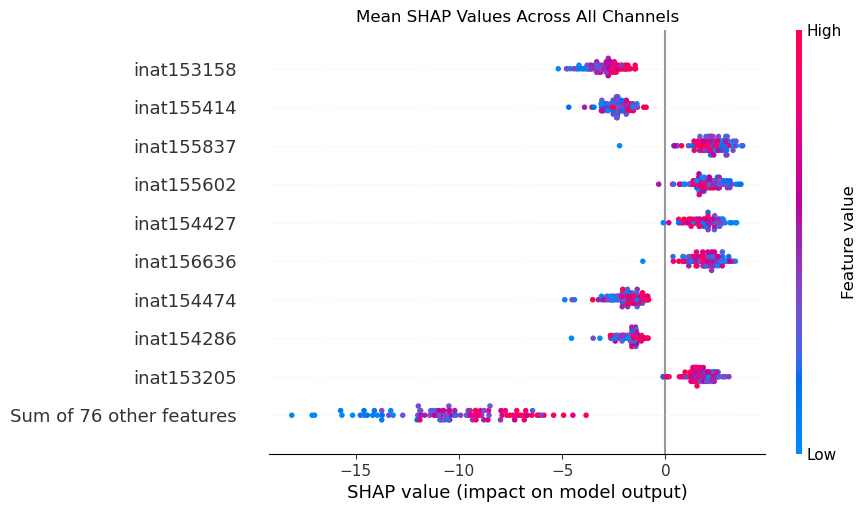

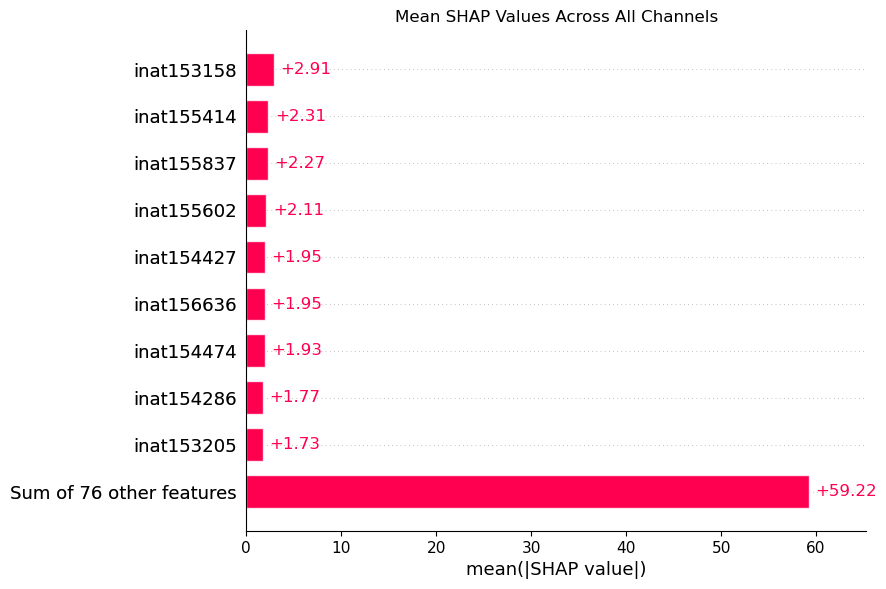

In [18]:
# This is an "overall" SHAP value plot, averaging across all channels

mean_values = shap_values.values.mean(axis=2)  
mean_shap = shap.Explanation(values=mean_values,
                              data=shap_values.data, feature_names=shap_values.feature_names) 

shap.plots.beeswarm(mean_shap, max_display=10, show=False)
plt.title('Mean SHAP Values Across All Channels')
plt.show()
shap.plots.bar(mean_shap, max_display=10, show=False)
plt.title('Mean SHAP Values Across All Channels')
plt.show()


In [31]:
# Now we try classical regression methods to compare results
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Define a function to train and evaluate a regression model
def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return mse, mae, r2, training_time

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}


# Use the best parameters found
best_one_every = 1  # Change this to the best one_every found
best_params = best_parameters[f'one_every_{best_one_every}']
print(f'Best parameters for one_every={best_one_every}: {best_params}')

X_temp, freq_chan = extract_features(raw_data, one_every=best_one_every)
X = X_temp[X_temp.columns[1:2+freq_chan]]
y = X_temp[X_temp.columns[-84:]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


# Train and evaluate each model
results = {}
for model_name, model in models.items():
    mse, mae, r2, training_time = train_and_evaluate(model, X_train_std, y_train, X_test_std, y_test)
    results[model_name] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'Training Time': training_time
    }




Best parameters for one_every=1: {'activation': 'relu', 'neurons': 128, 'layers': 2, 'mse': 0.04199244976043701, 'mae': 0.14574085175991058, 'r2': 0.9902734756469727, 'training_time': 48.48757553100586}


In [32]:
results

{'Linear Regression': {'MSE': 0.032971485489650745,
  'MAE': 0.12428895616131226,
  'R2': 0.9925124834688498,
  'Training Time': 0.036298274993896484},
 'Random Forest': {'MSE': 0.2338196640622497,
  'MAE': 0.2711181178210678,
  'R2': 0.9430002728908873,
  'Training Time': 290.96818709373474}}

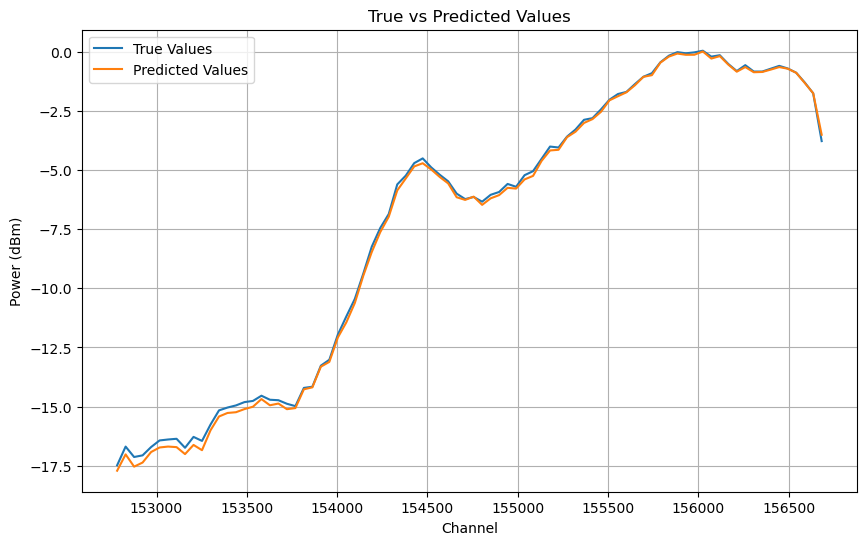

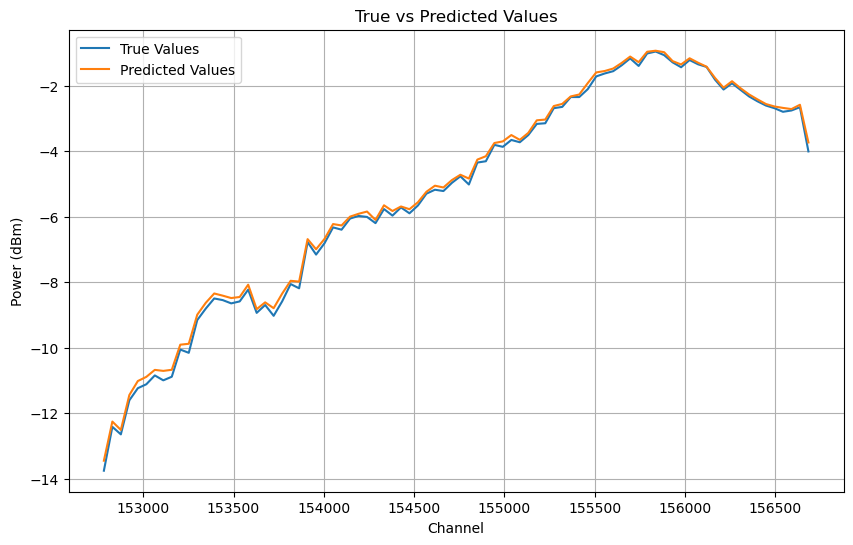

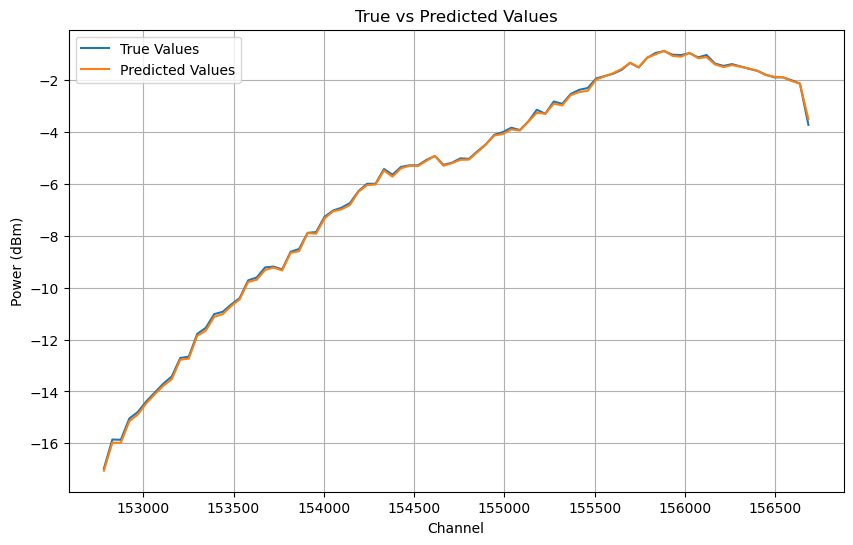

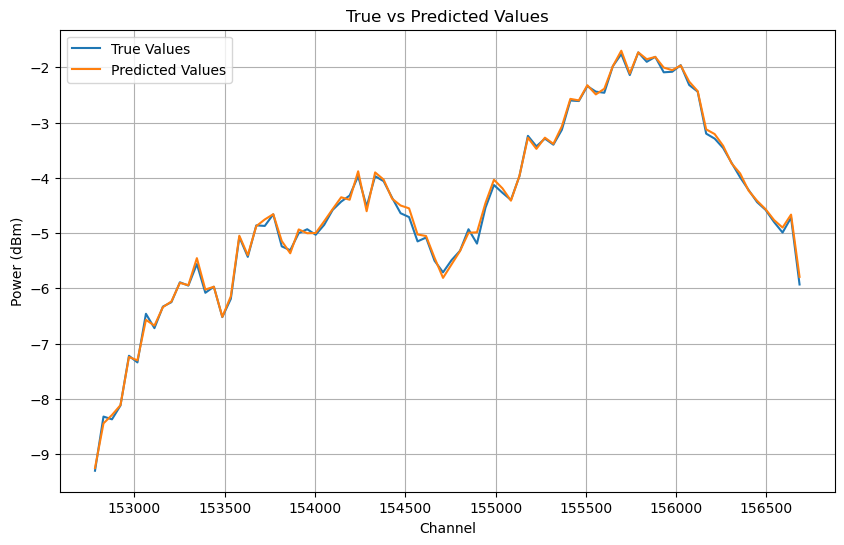

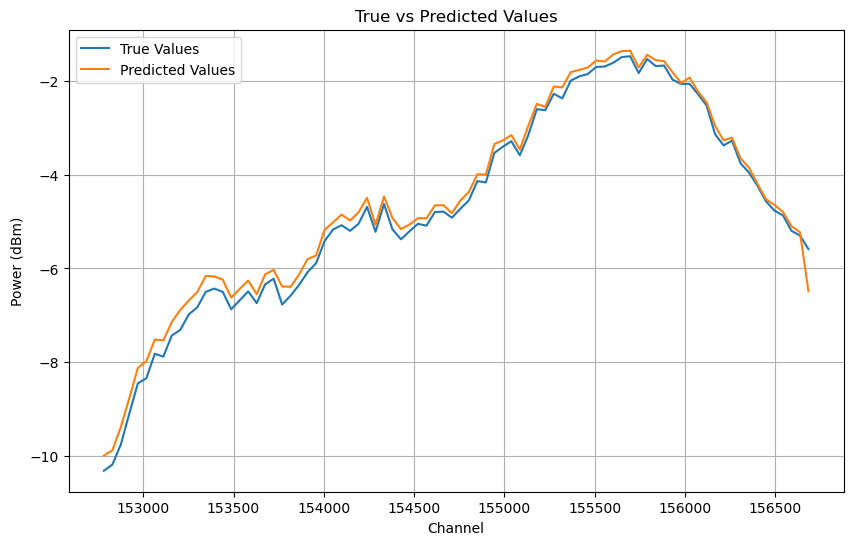

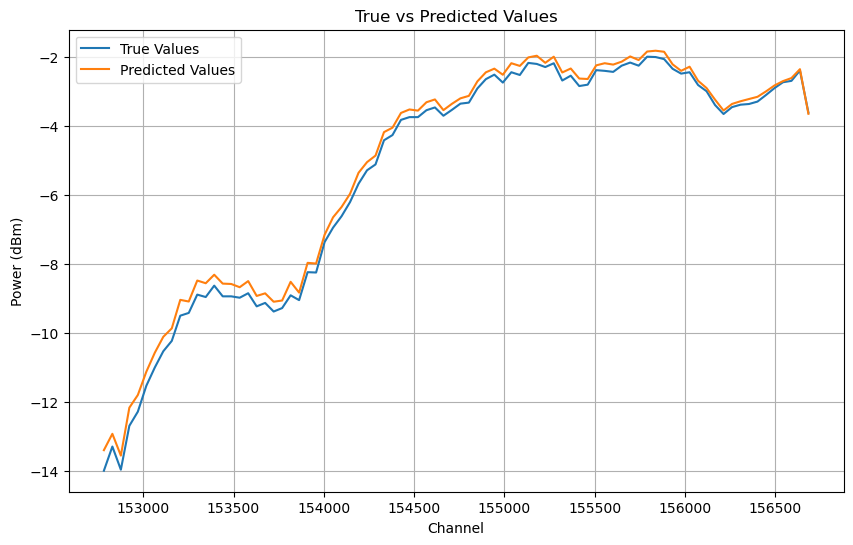

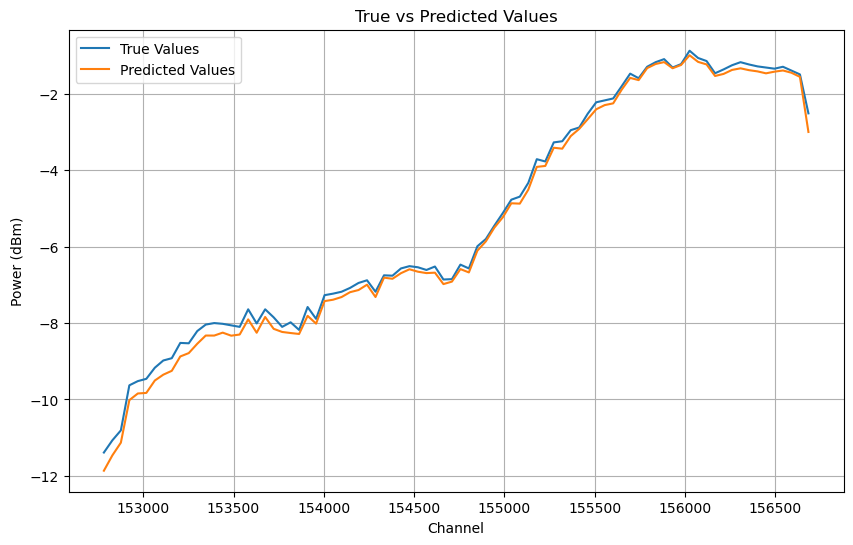

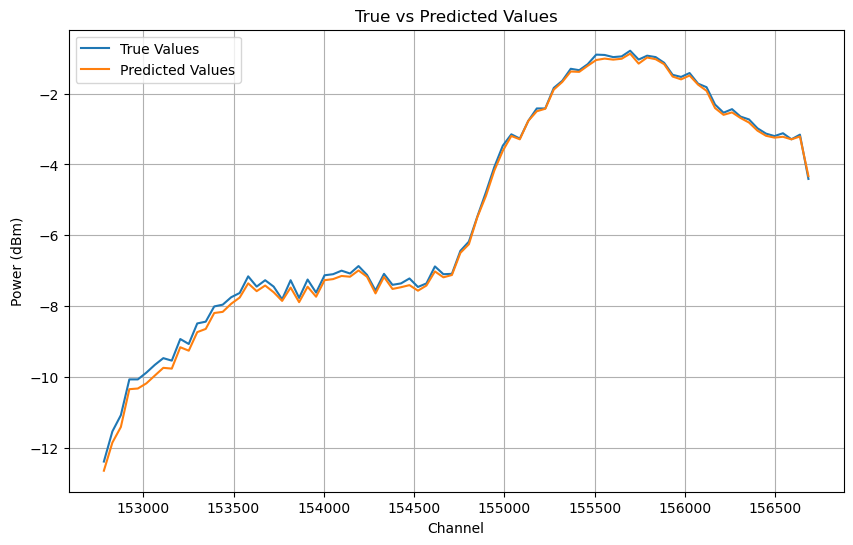

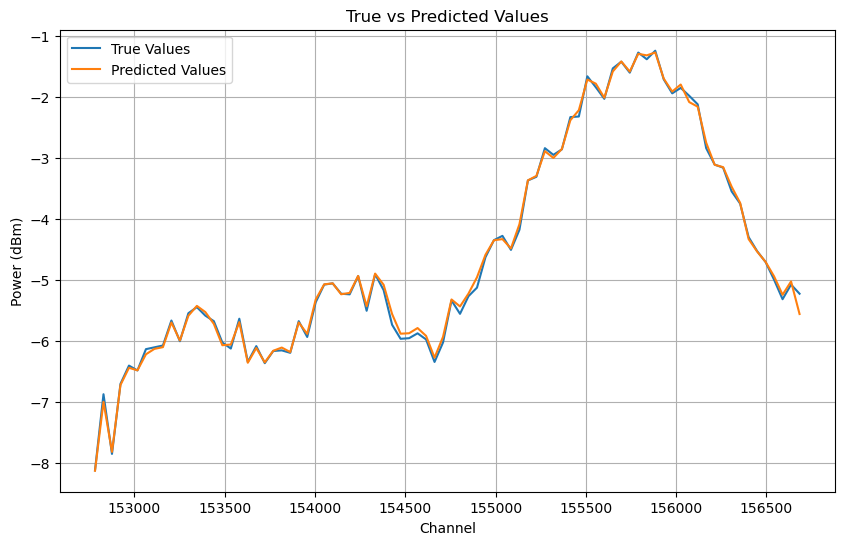

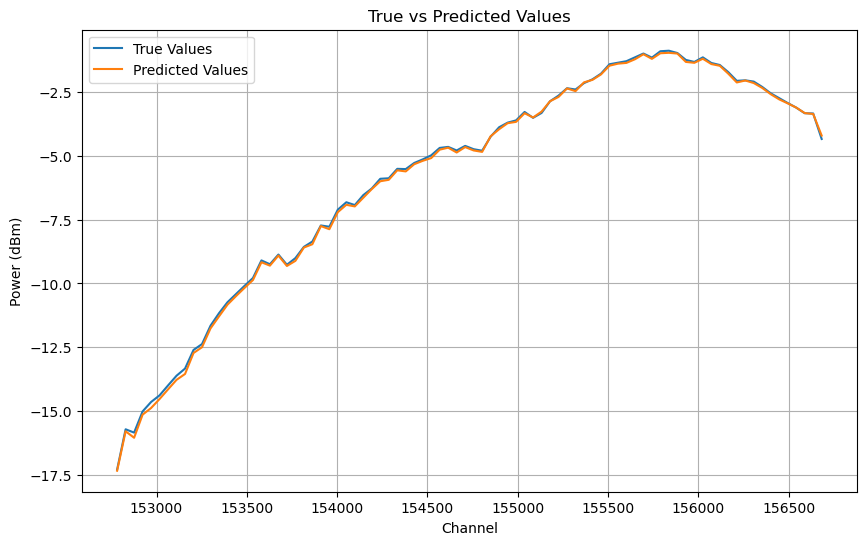

In [33]:
min_freq = 152782
max_freq = 156683

freqs = np.linspace(min_freq, max_freq, 84)

y_pred = models['Linear Regression'].predict(X_test_std)
# Convert predictions to DataFrame for easier plotting
y_pred = pd.DataFrame(y_pred, columns=y_test.columns)
for idx in range(10): 
    #Plot
    plt.figure(figsize=(10, 6))
    plt.plot(freqs, y_test.iloc[idx], label='True Values')
    plt.plot(freqs, y_pred.iloc[idx], label='Predicted Values')
    plt.title('True vs Predicted Values')
    plt.xlabel('Channel')
    plt.ylabel('Power (dBm)')
    plt.legend()
    plt.grid()
    plt.show()

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


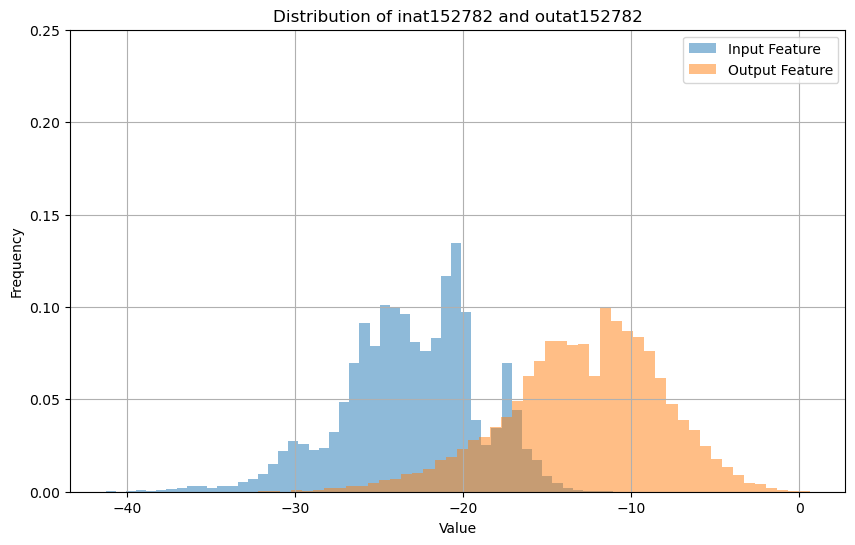

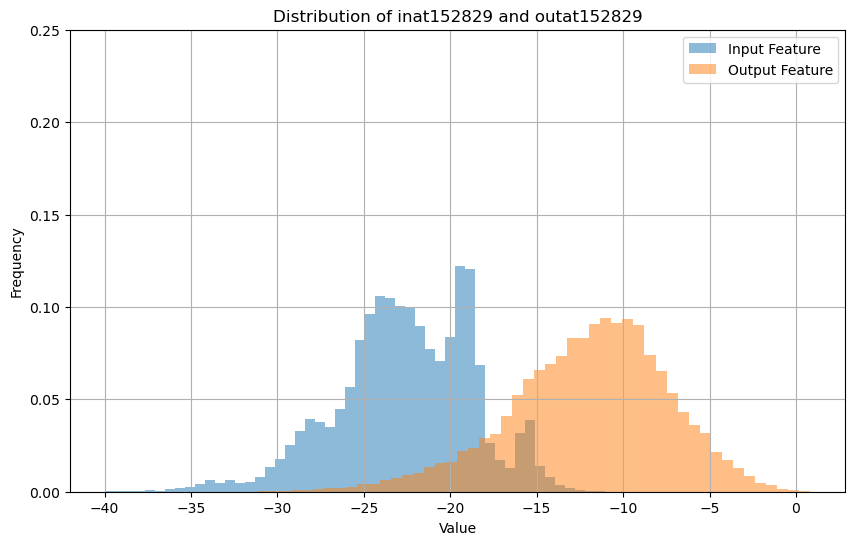

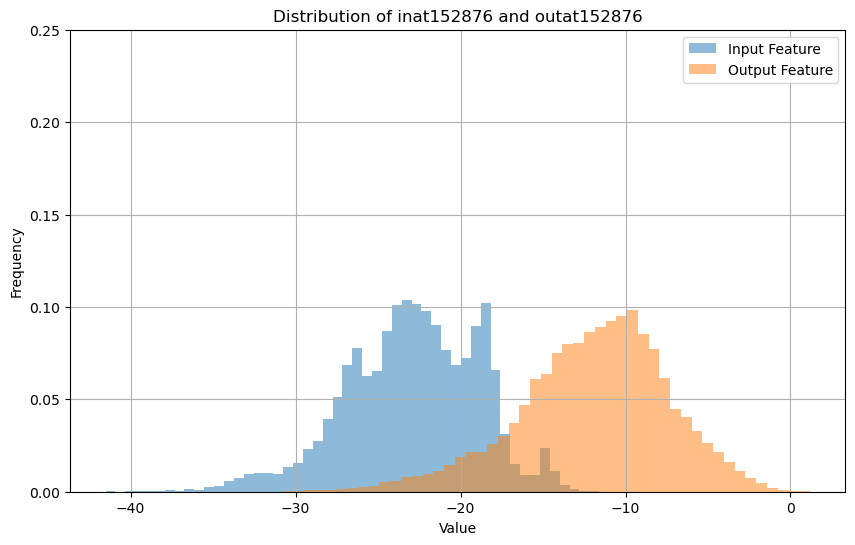

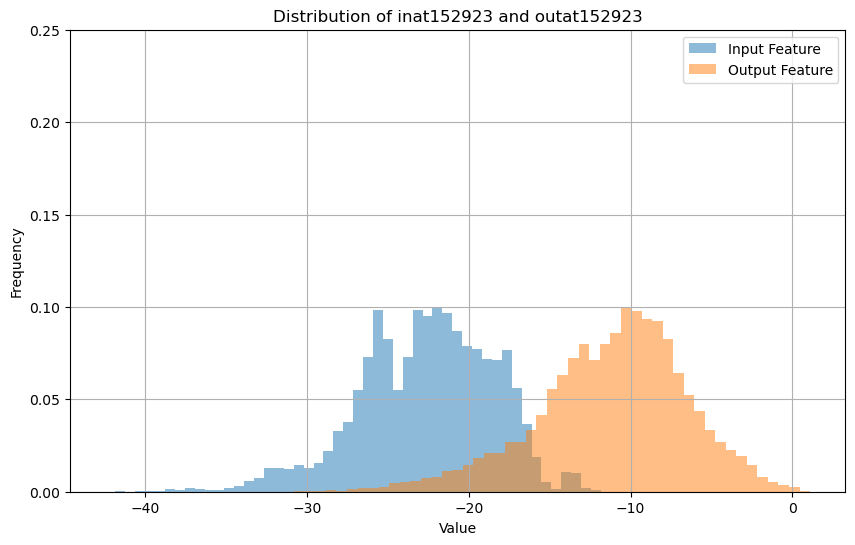

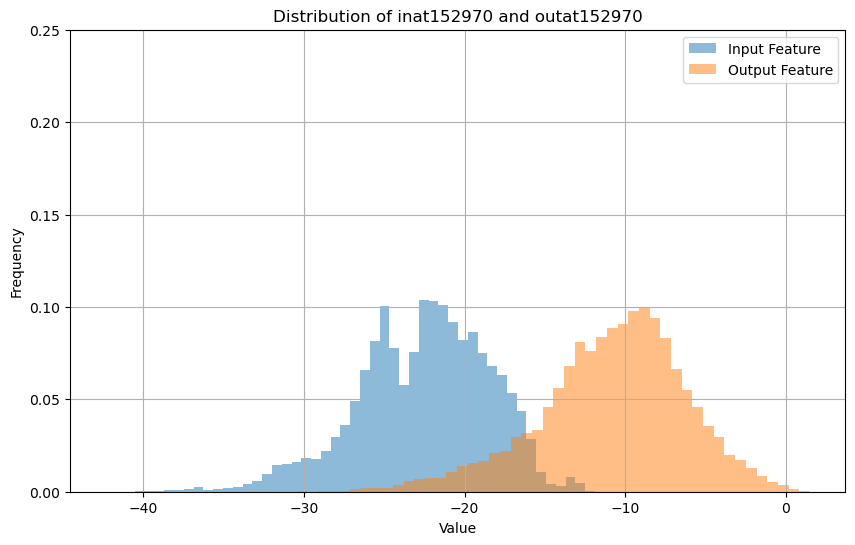

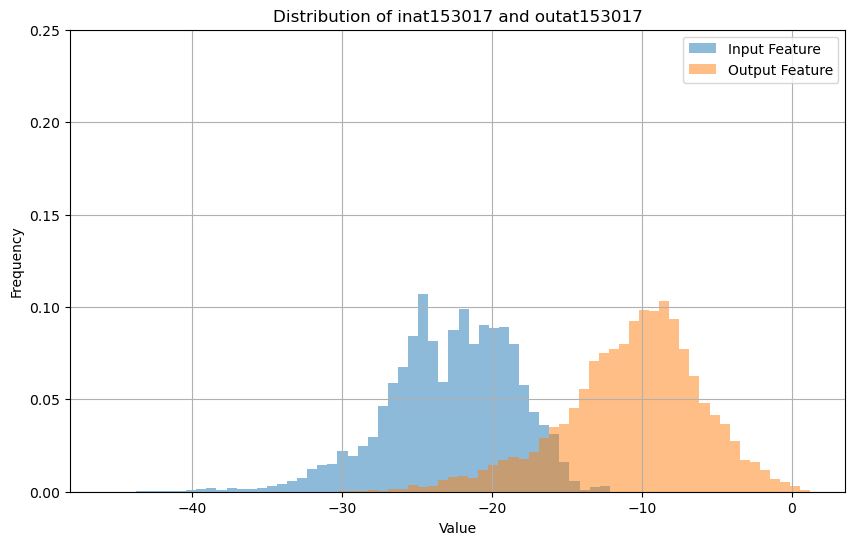

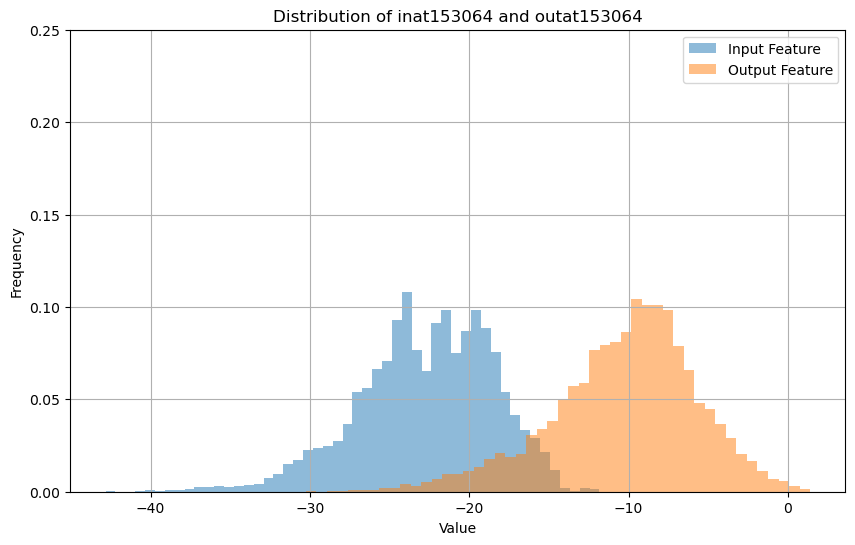

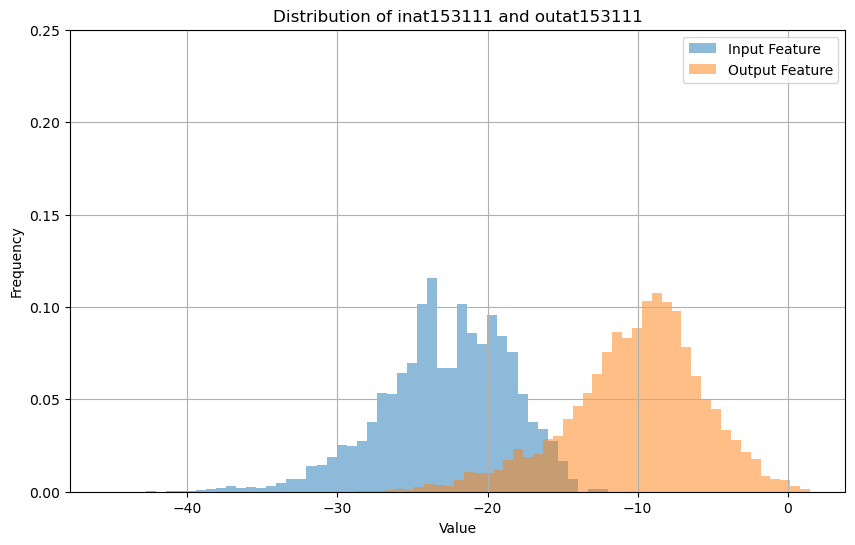

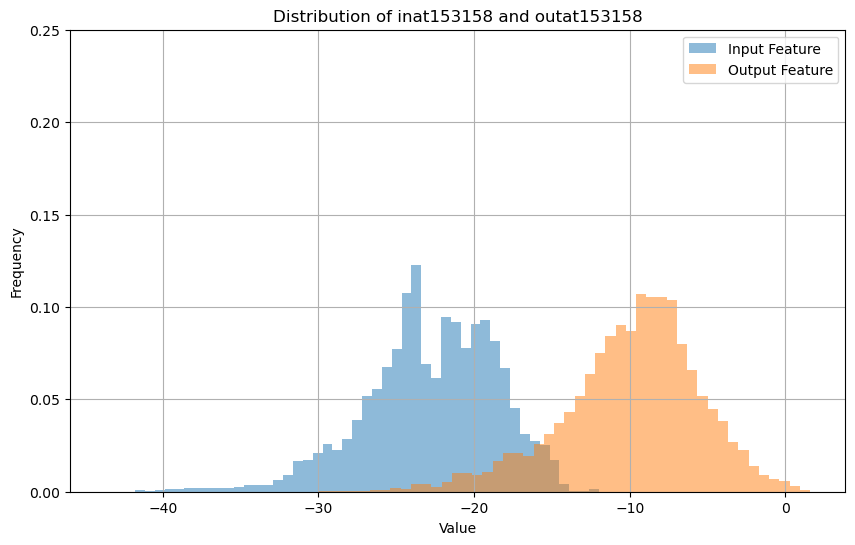

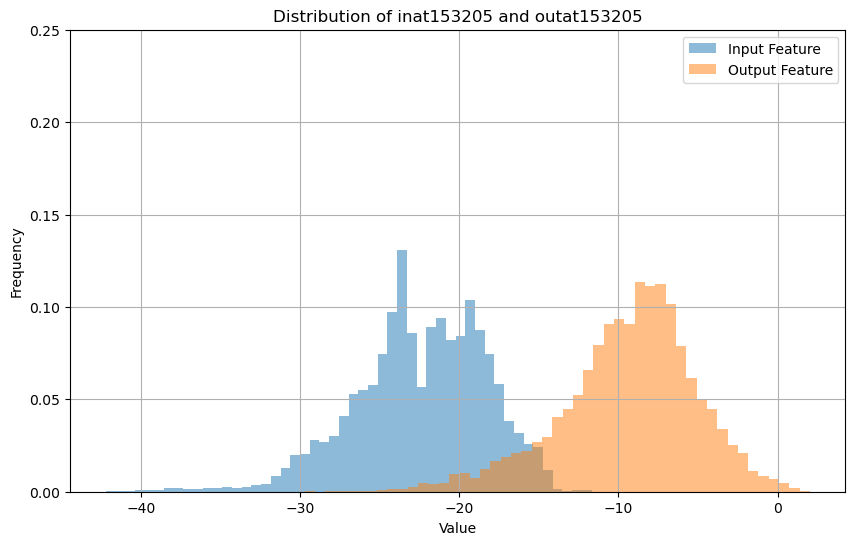

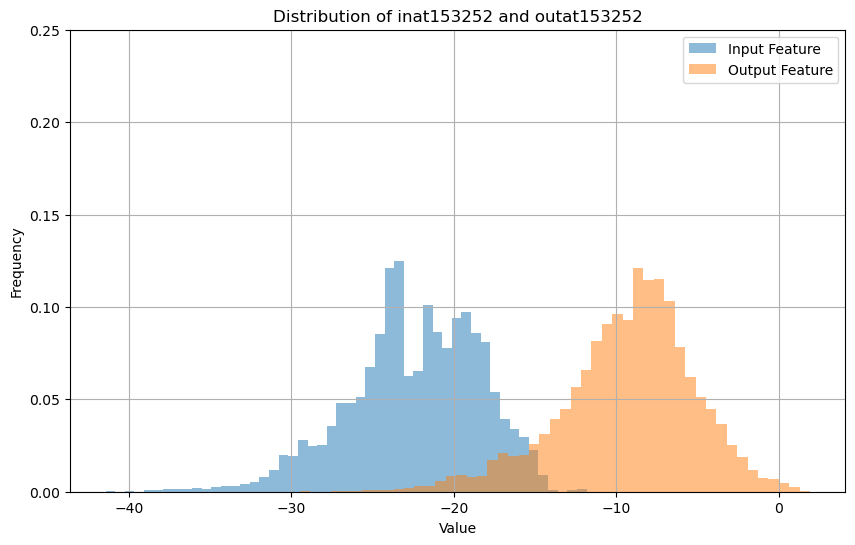

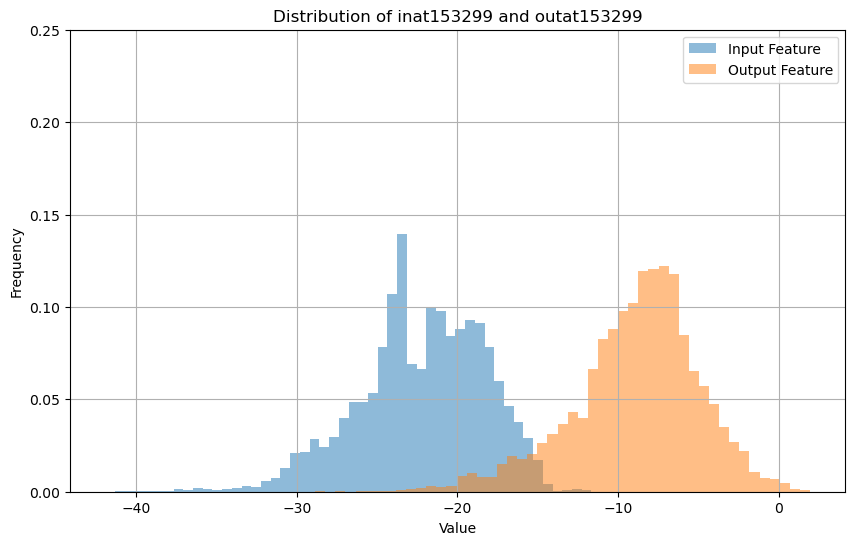

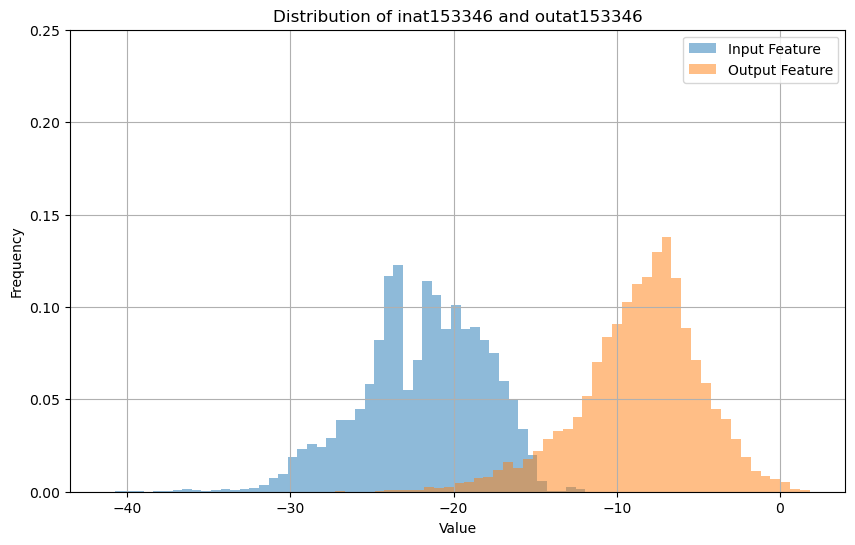

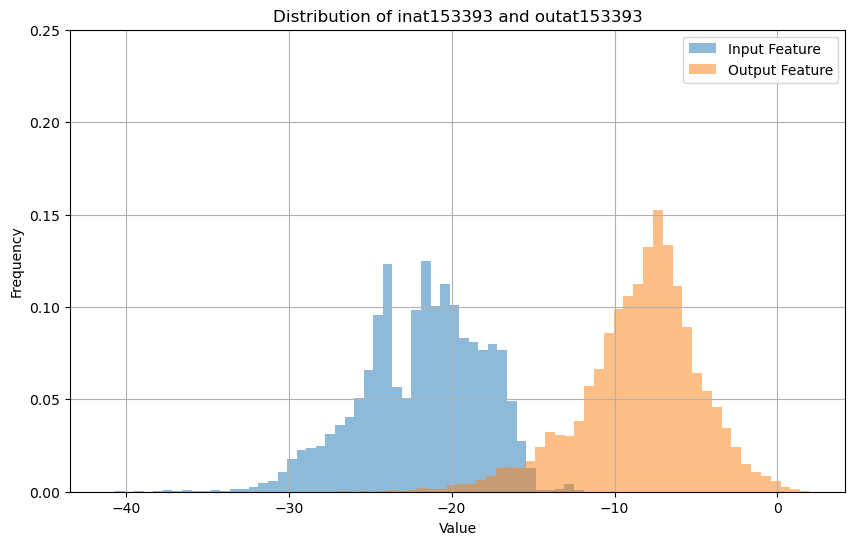

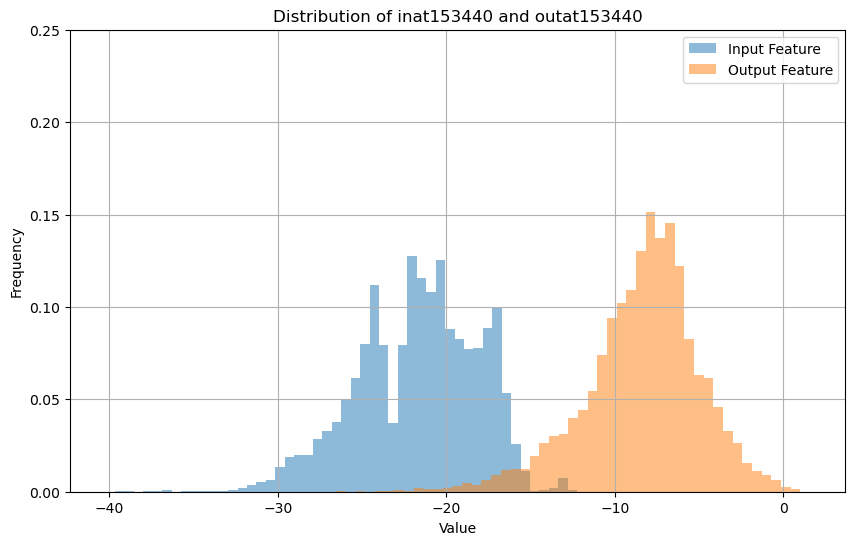

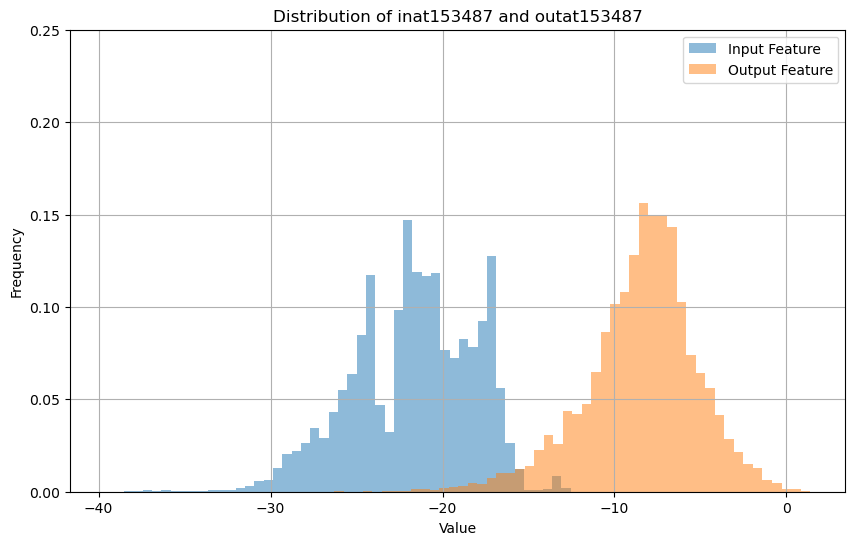

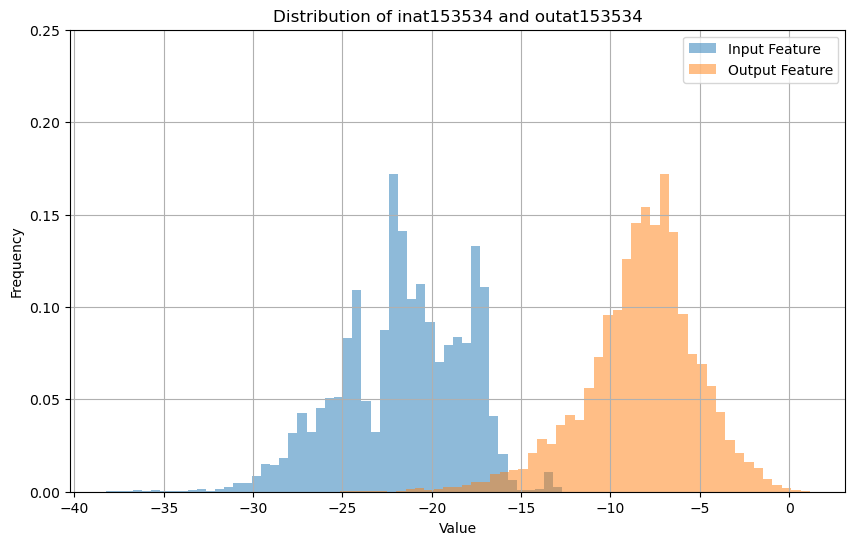

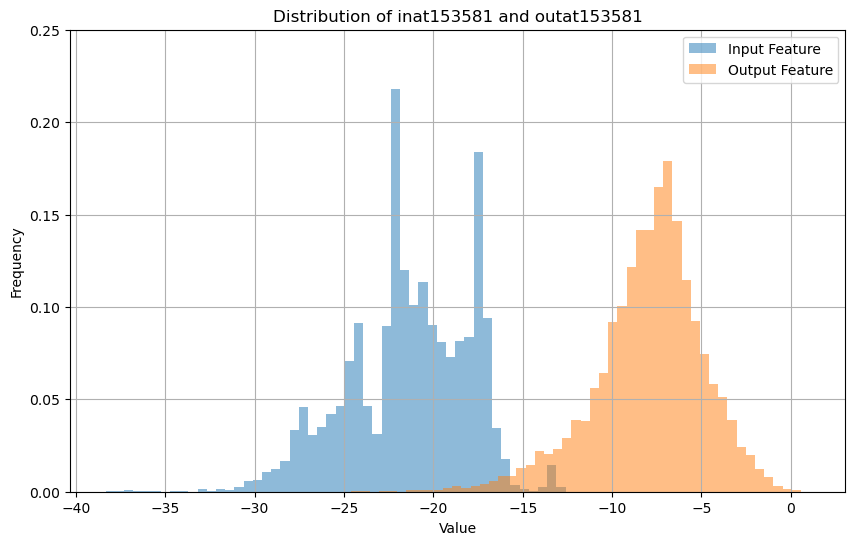

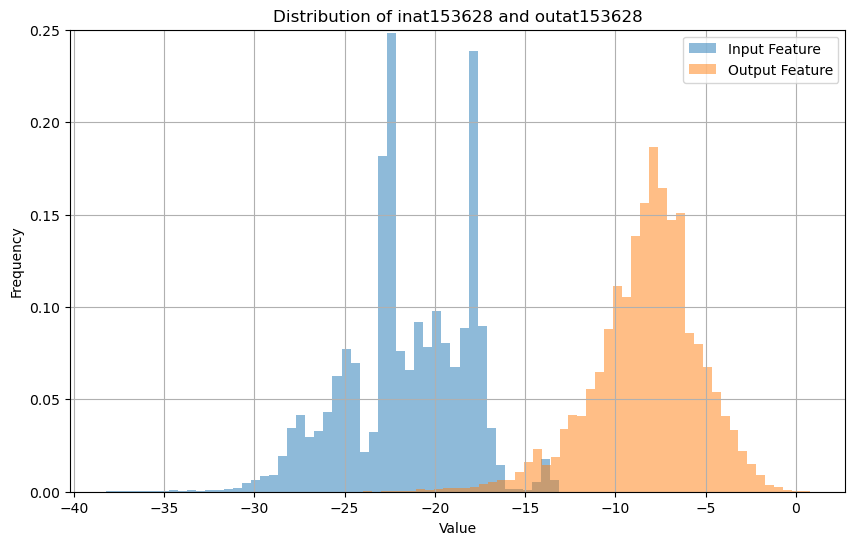

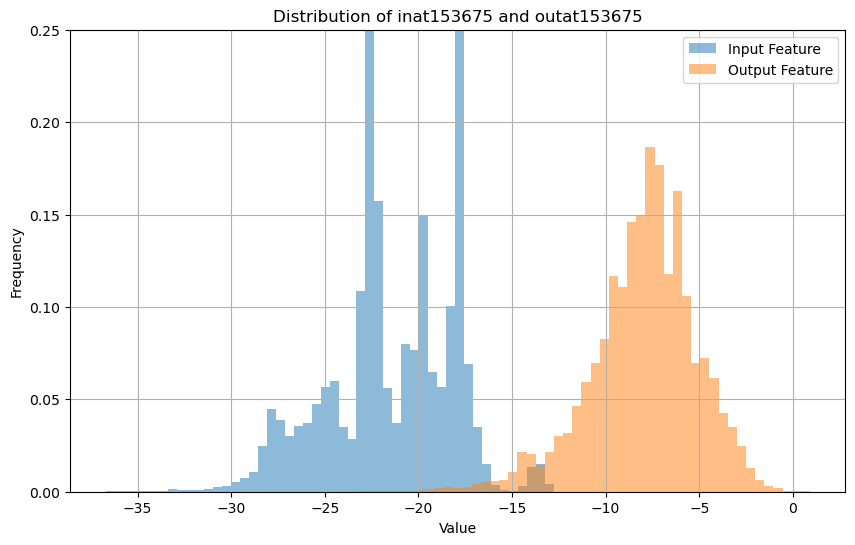

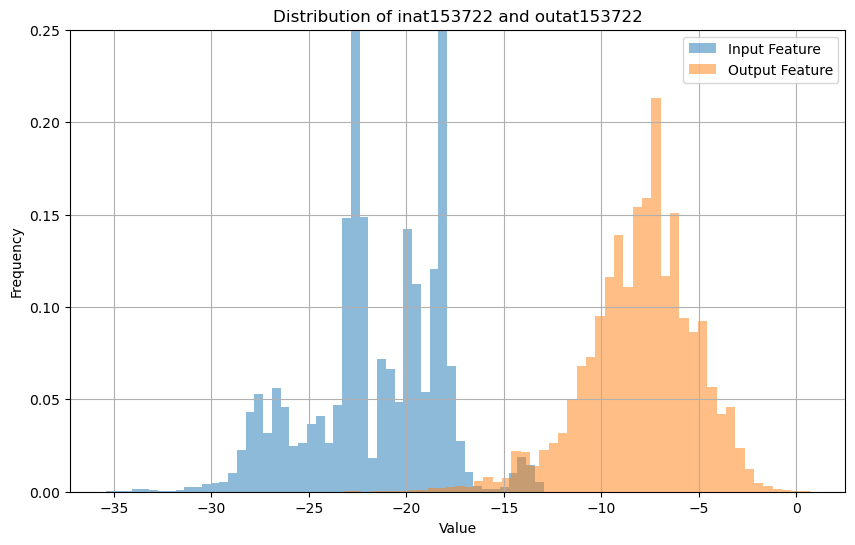

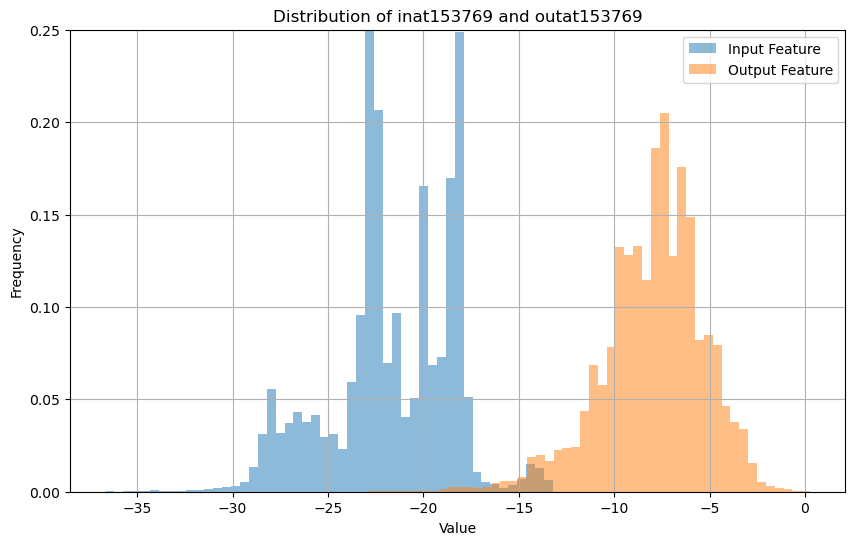

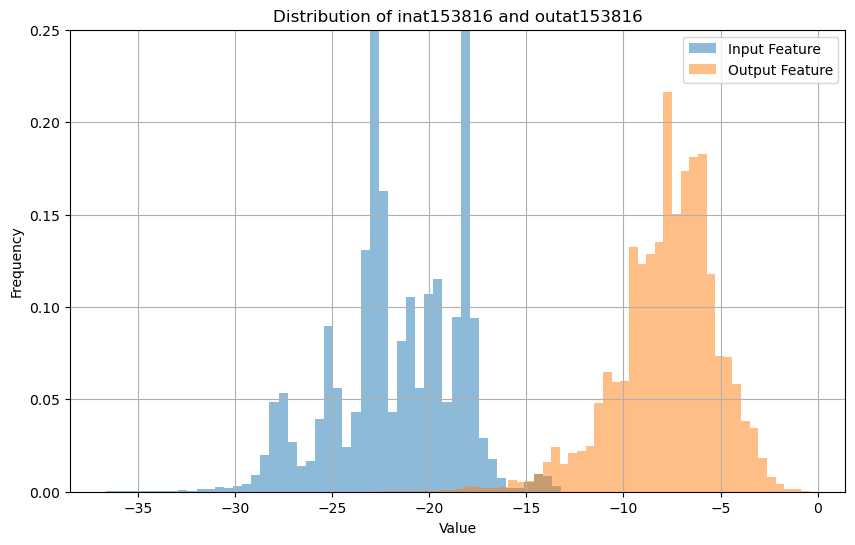

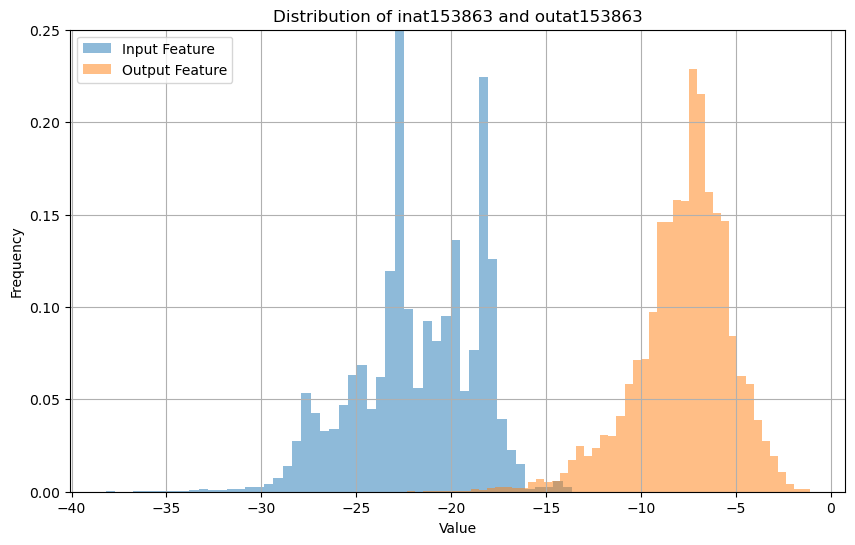

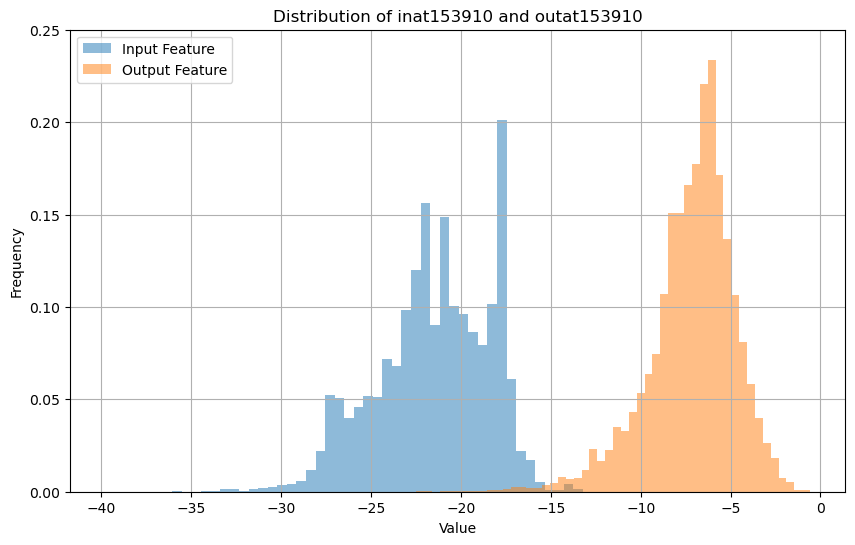

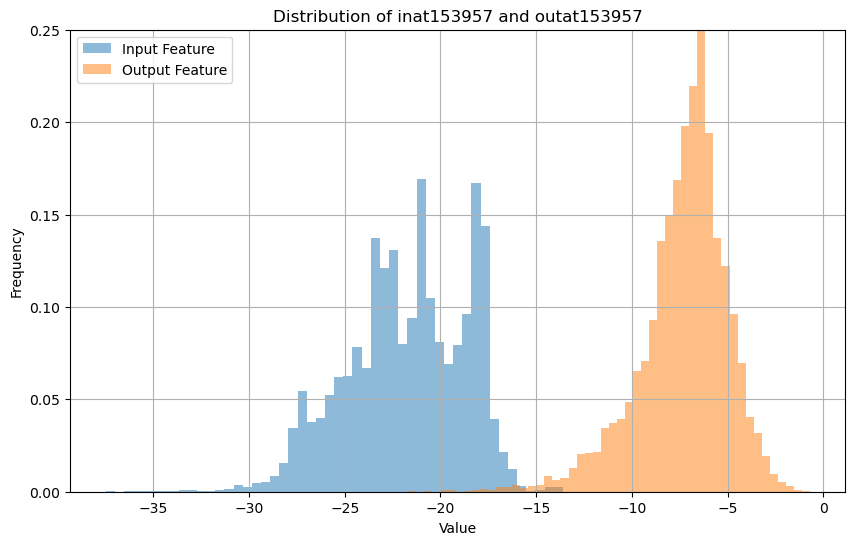

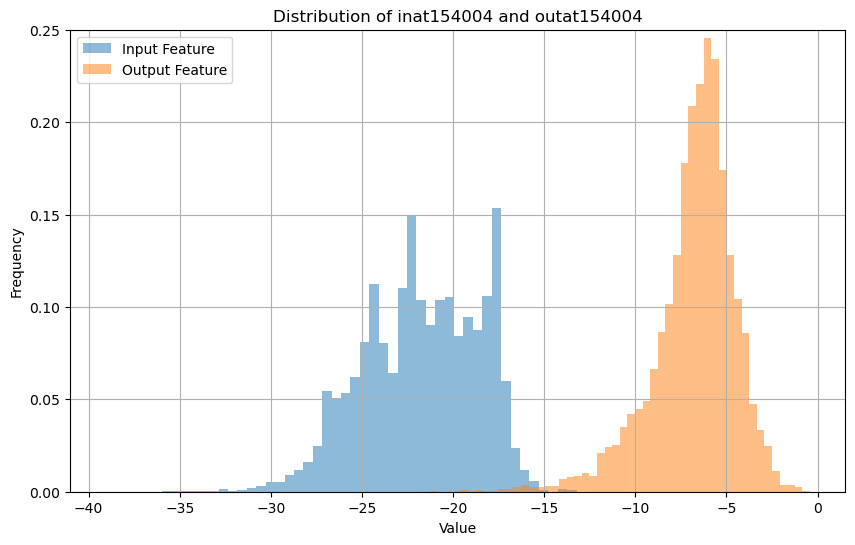

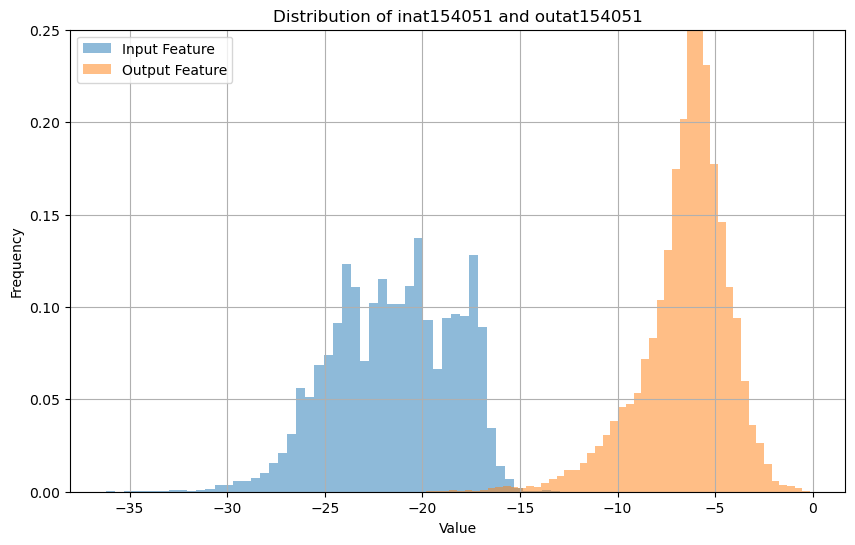

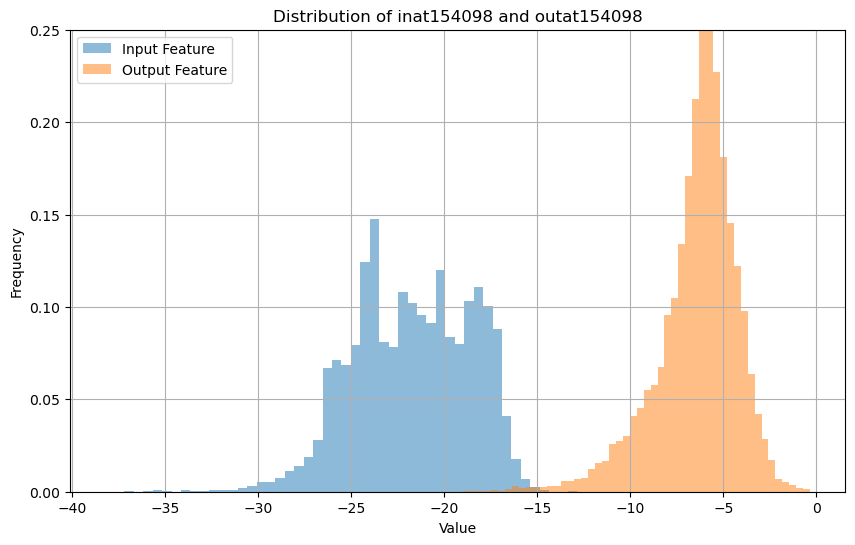

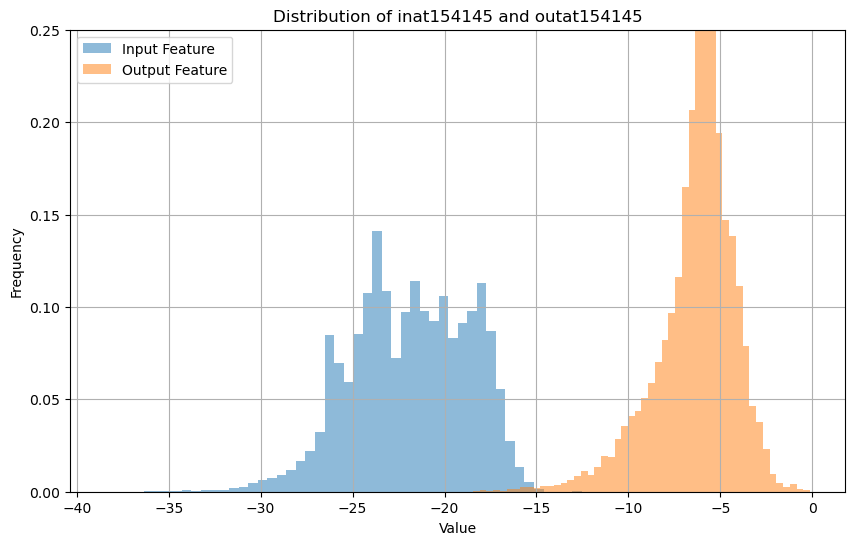

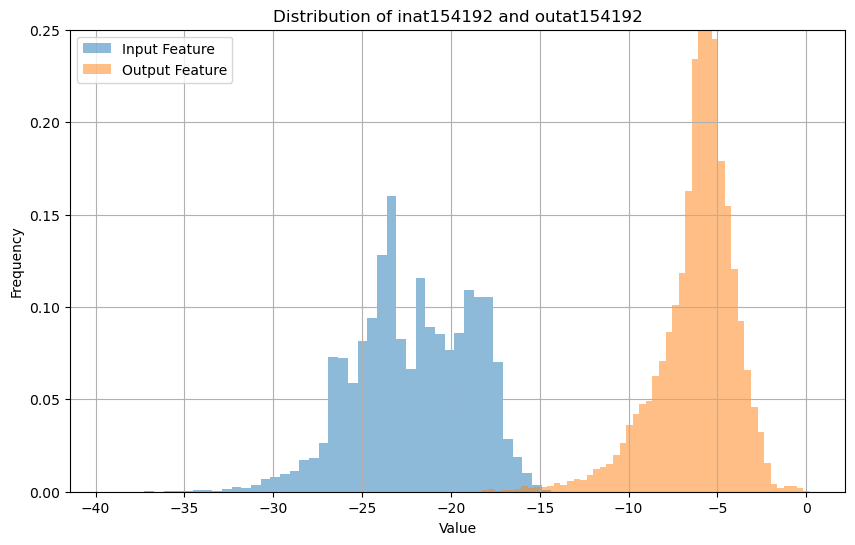

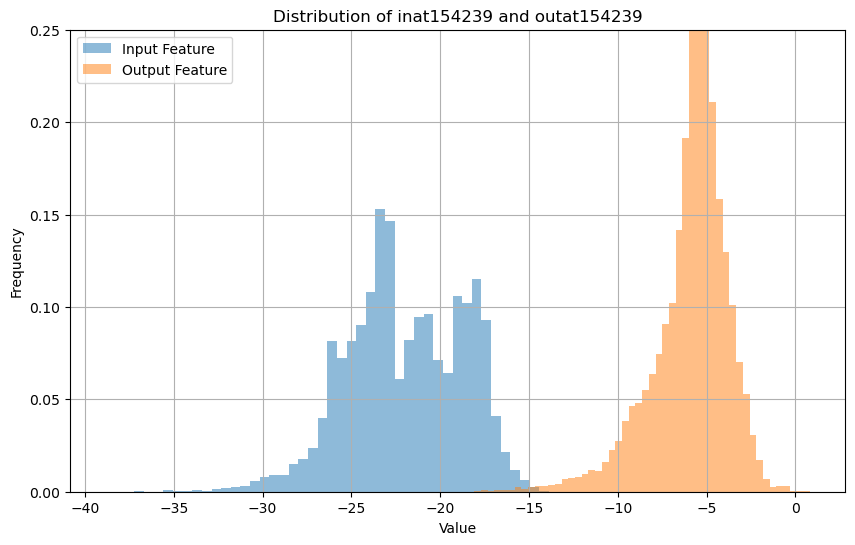

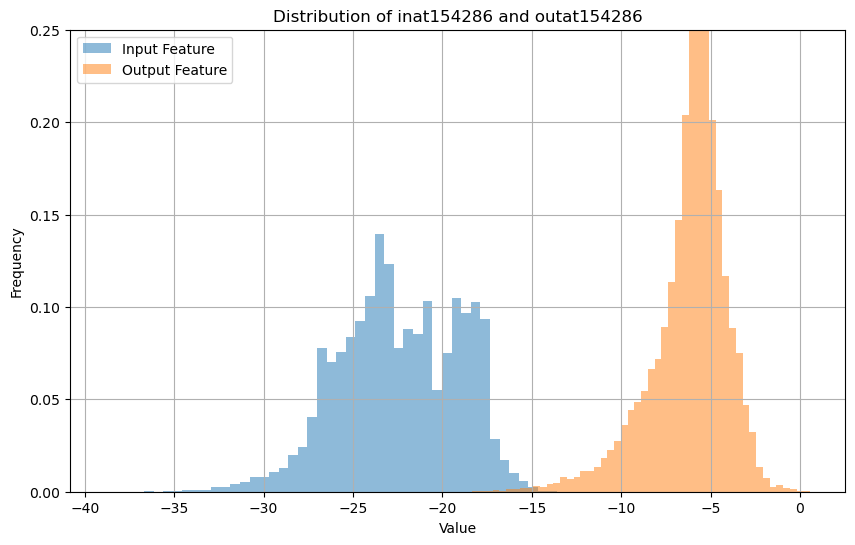

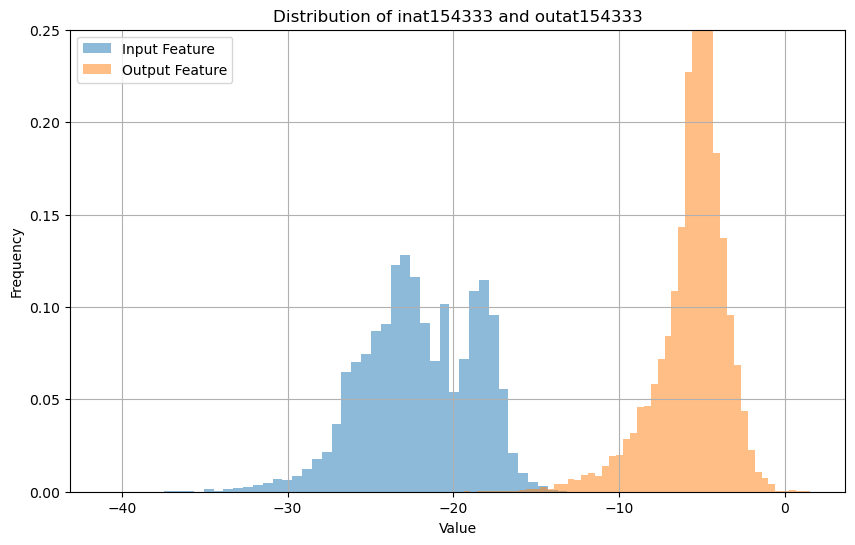

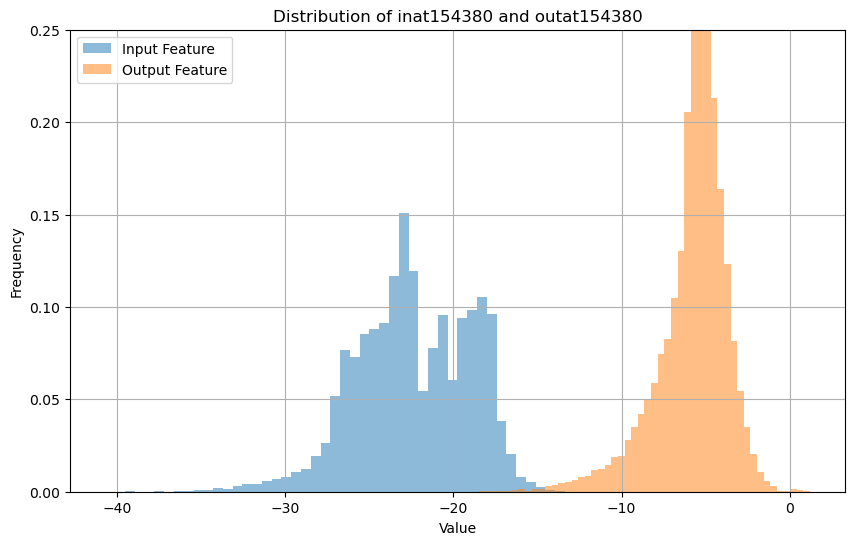

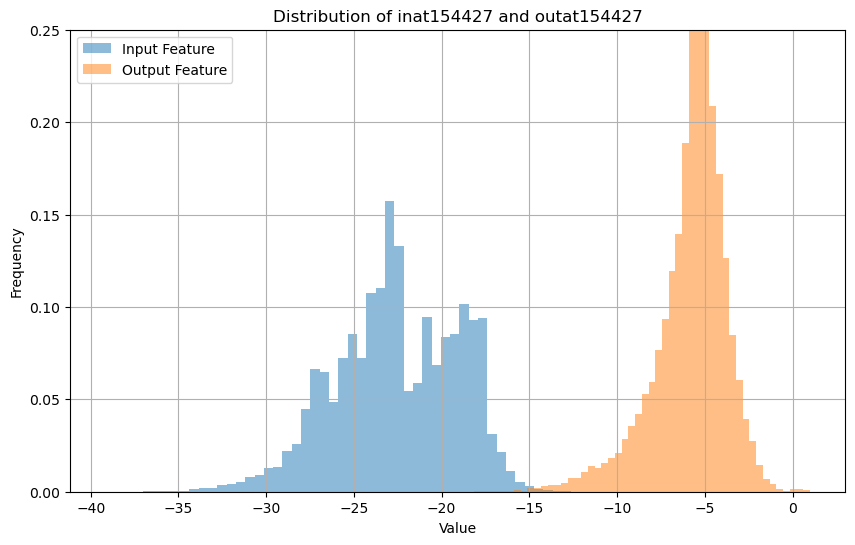

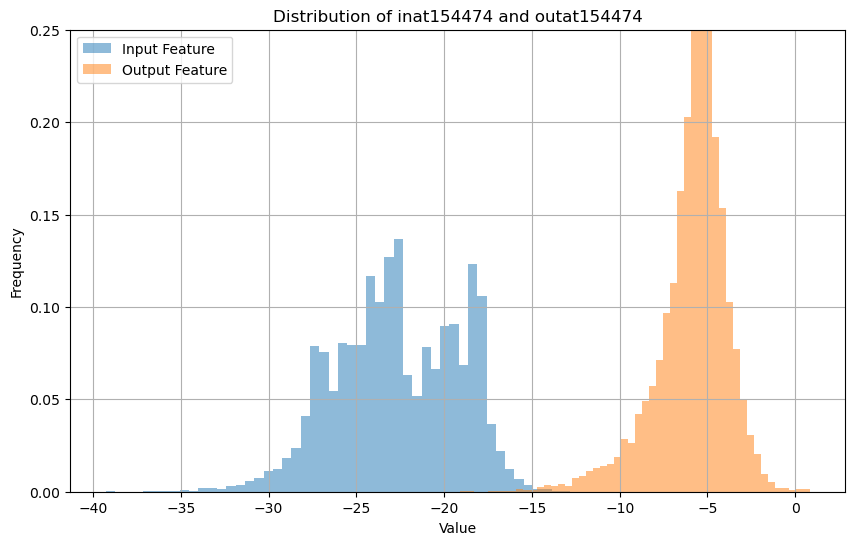

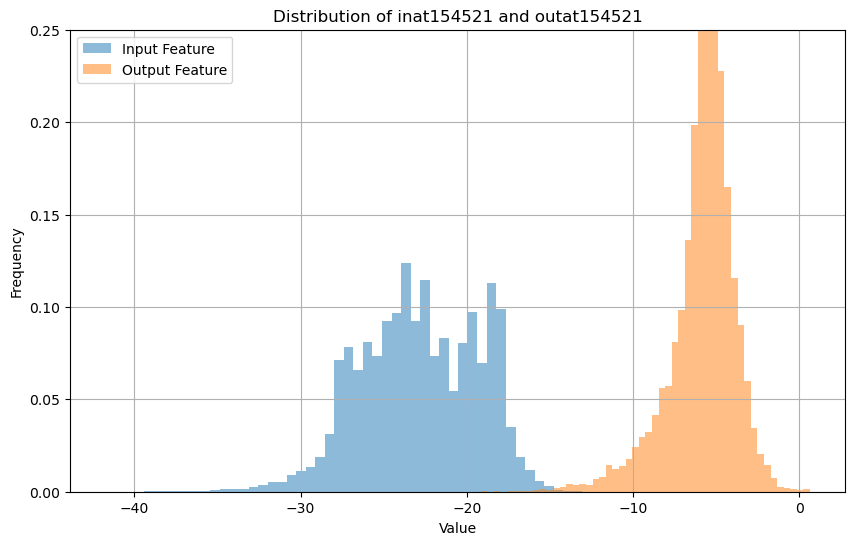

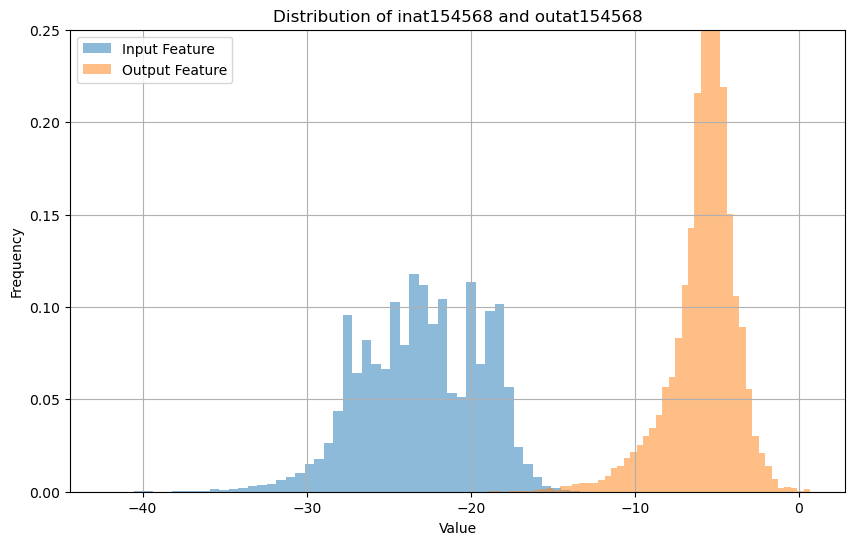

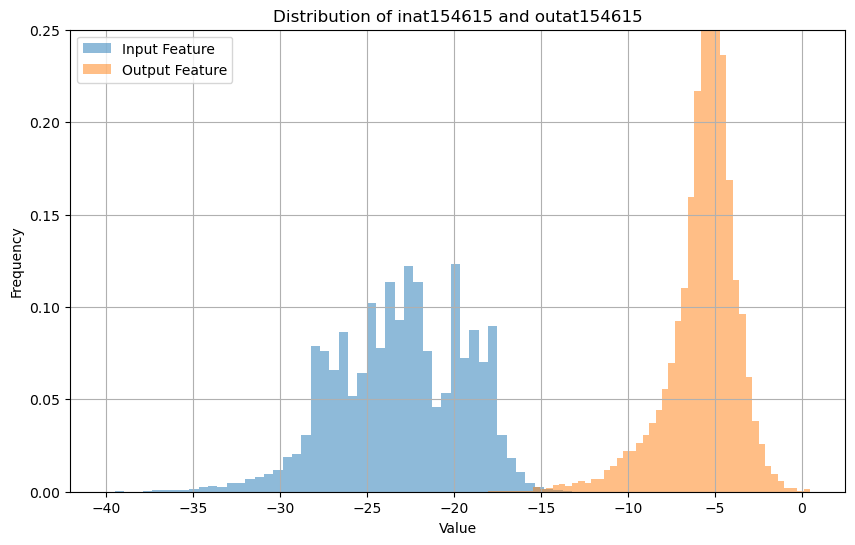

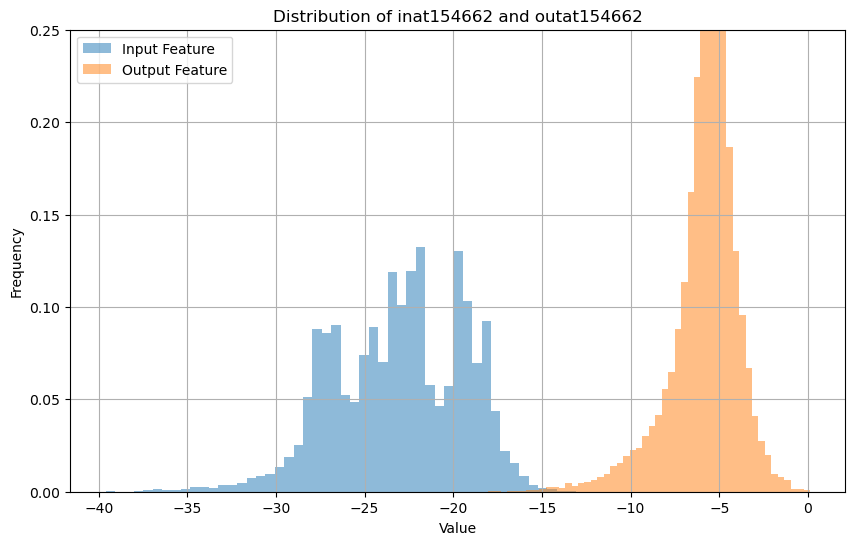

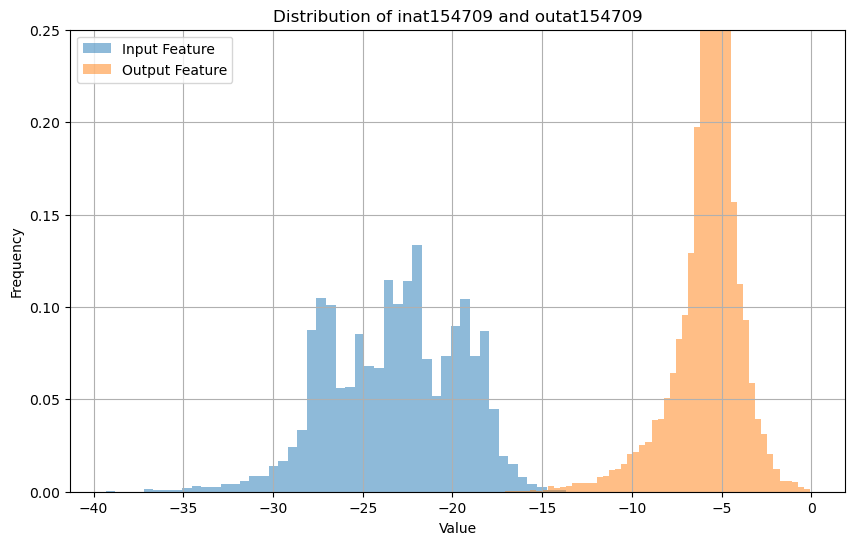

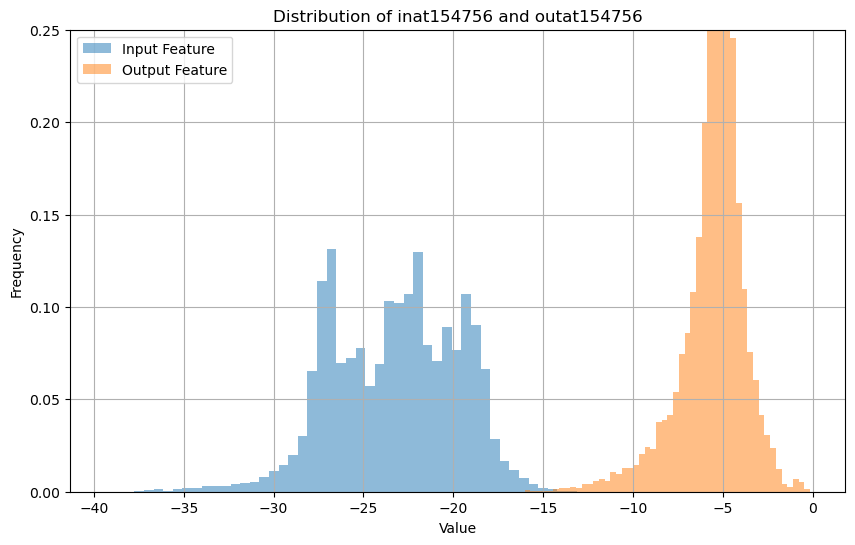

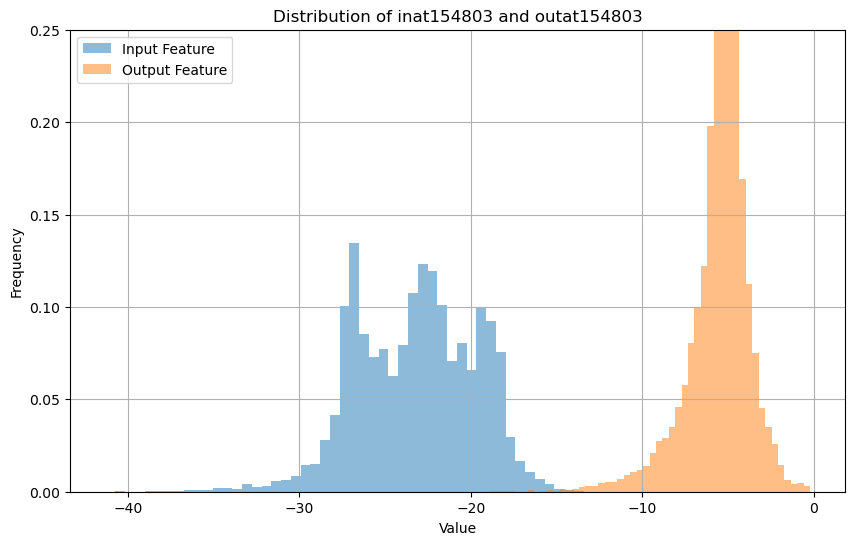

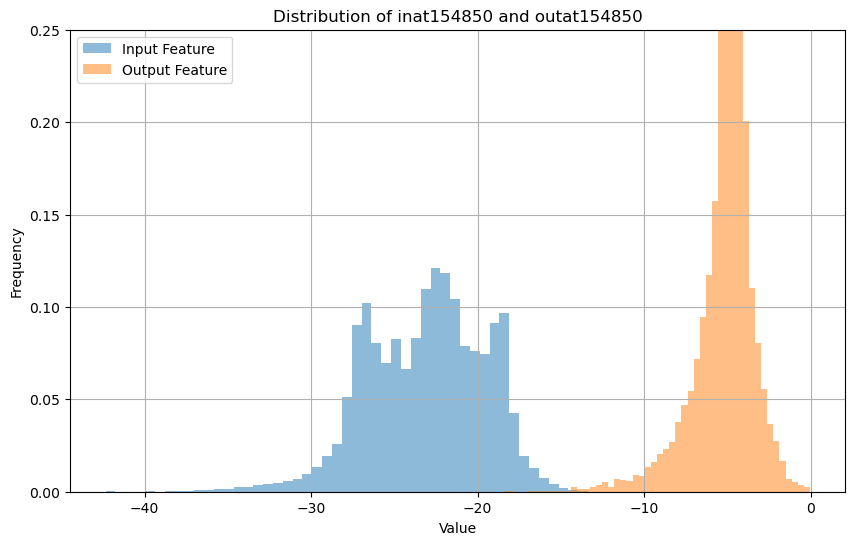

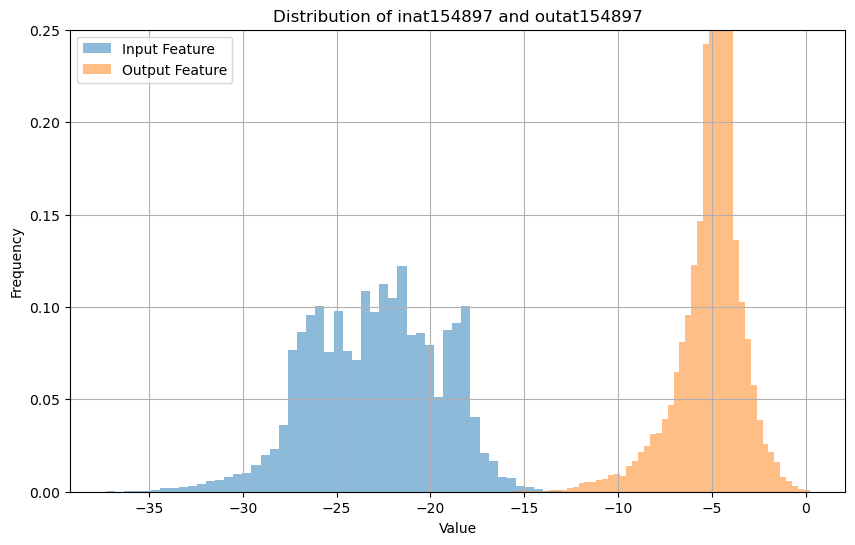

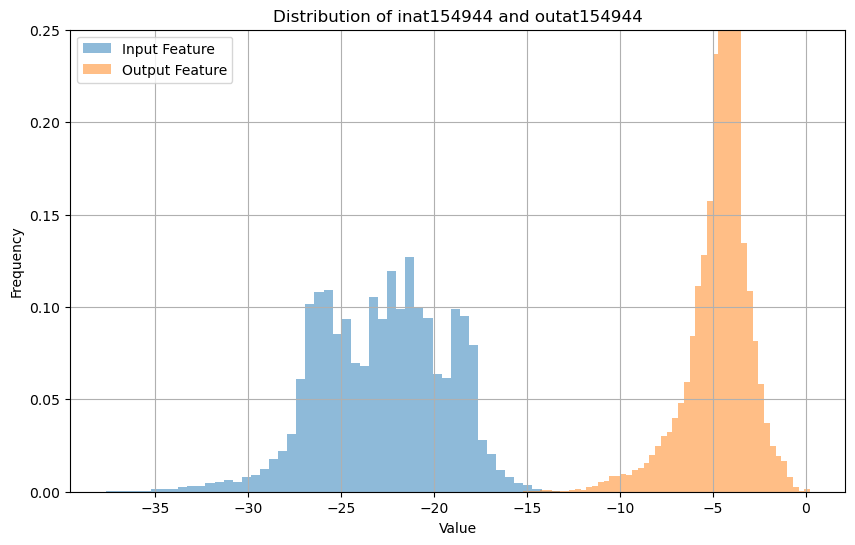

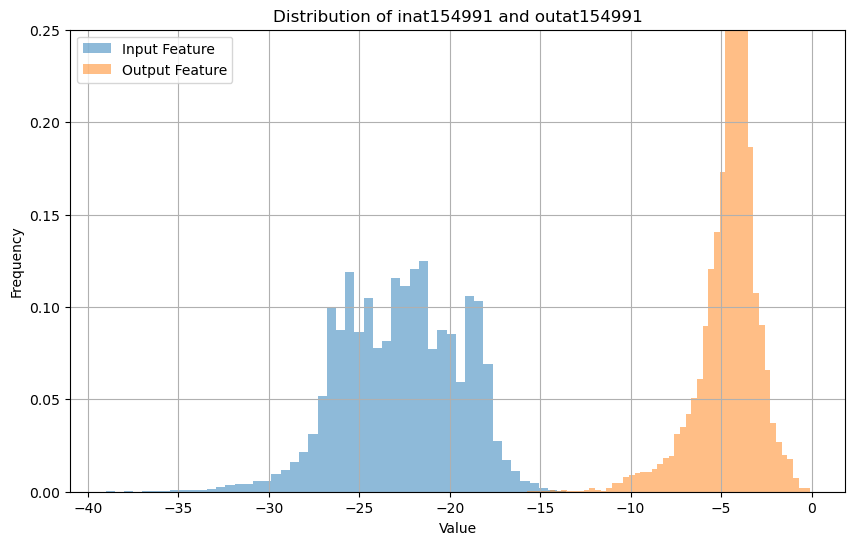

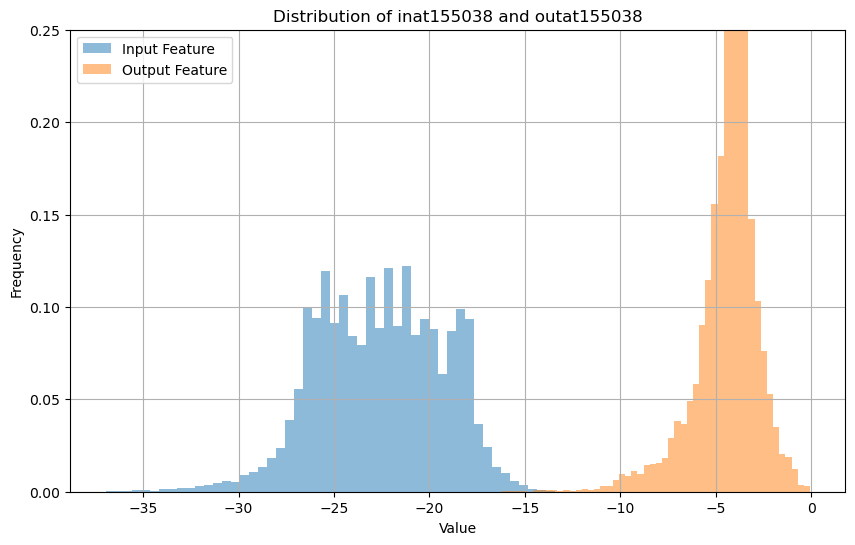

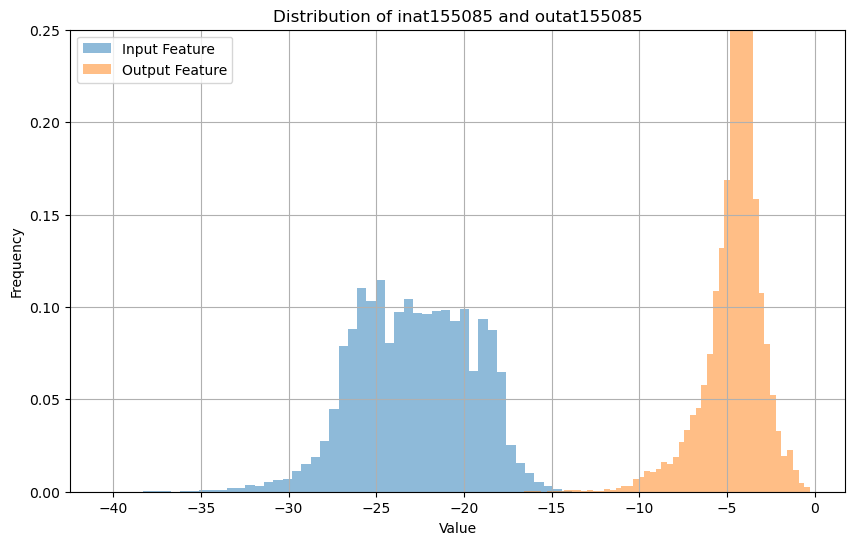

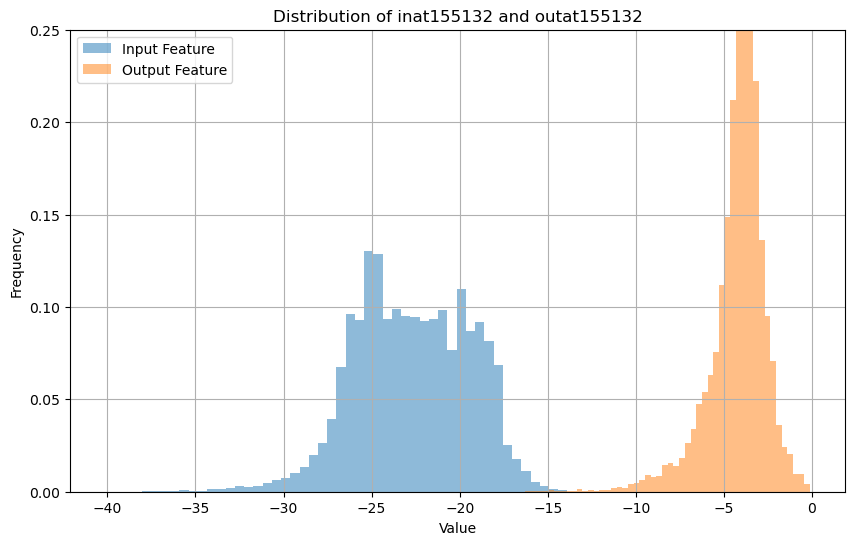

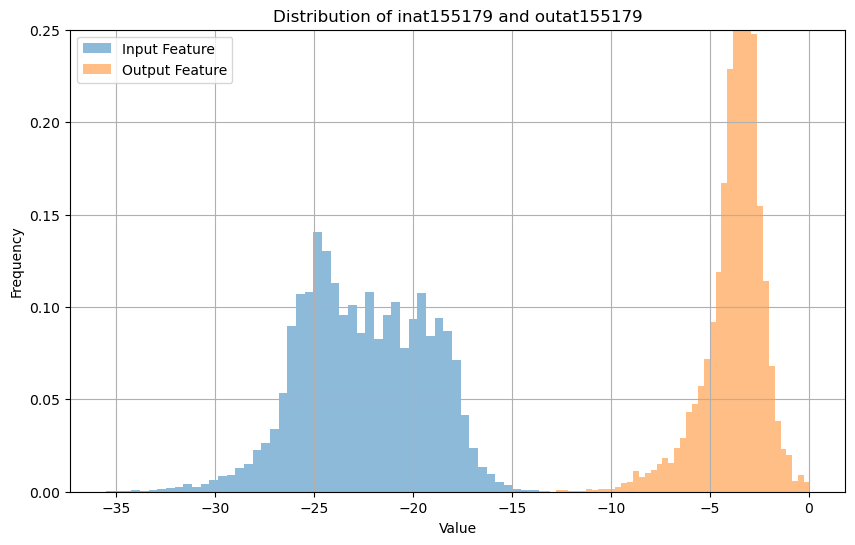

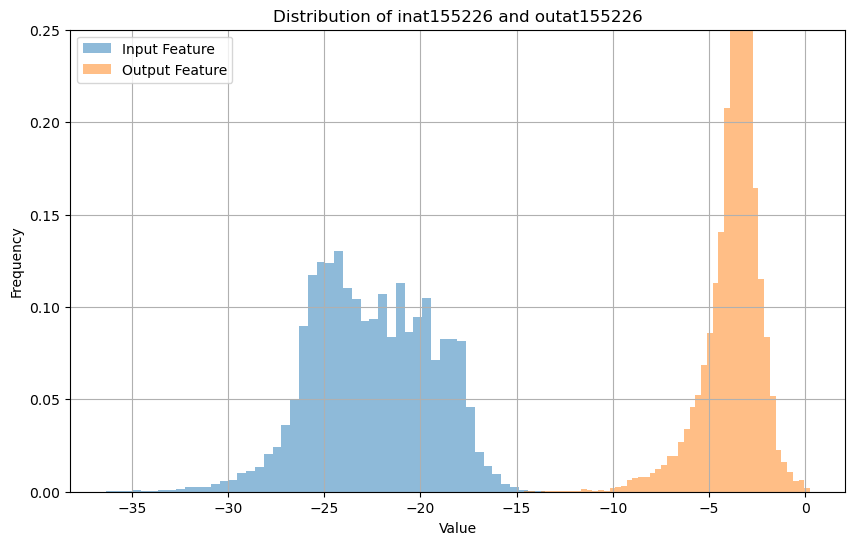

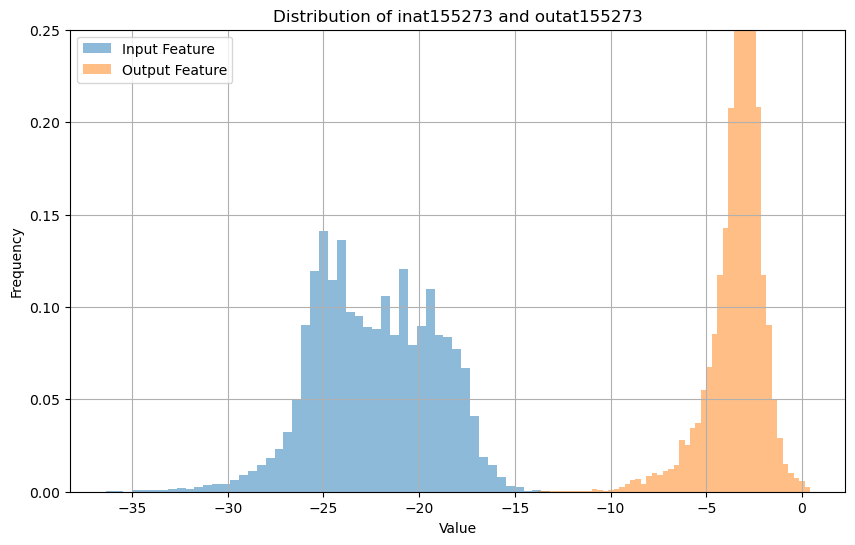

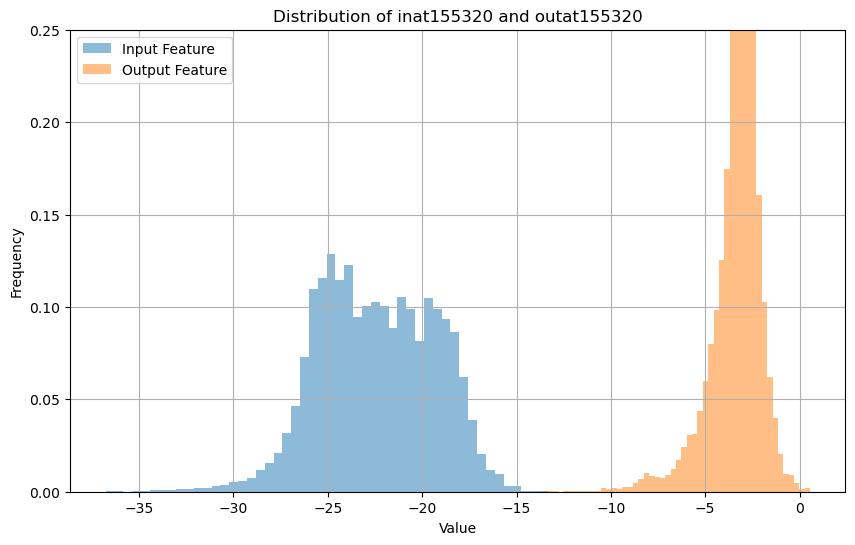

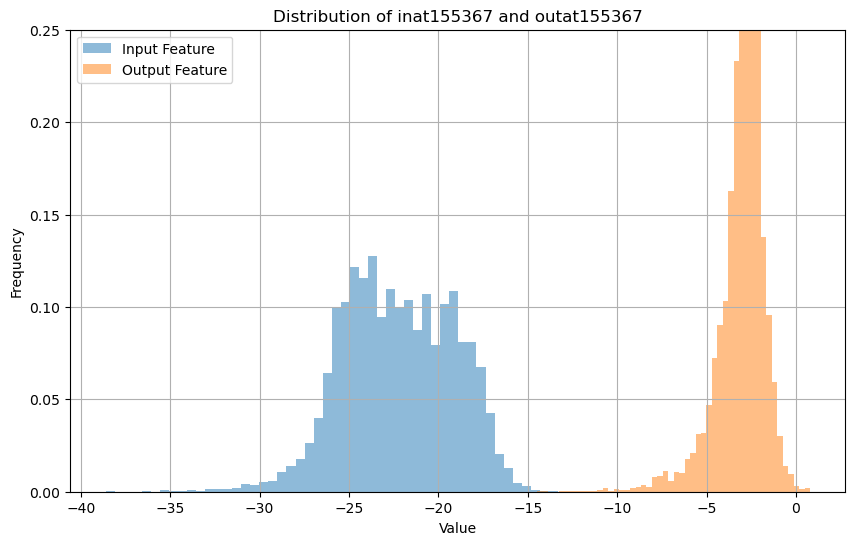

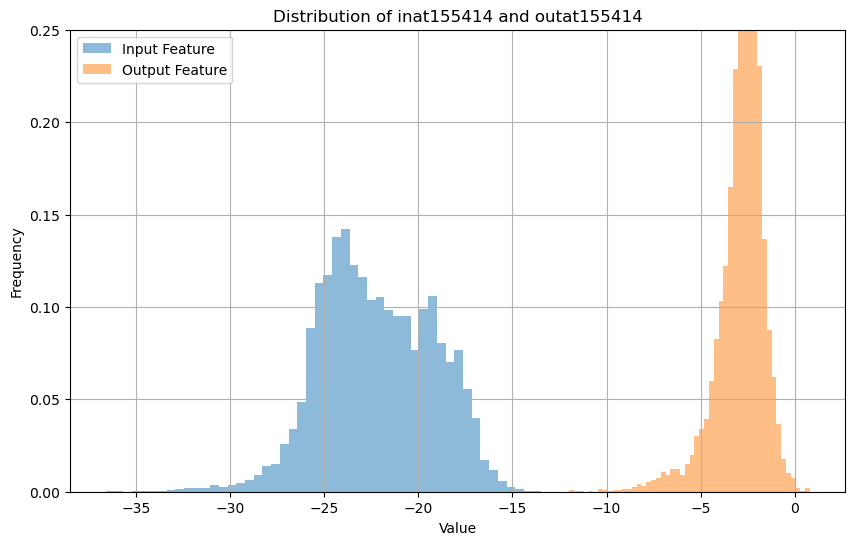

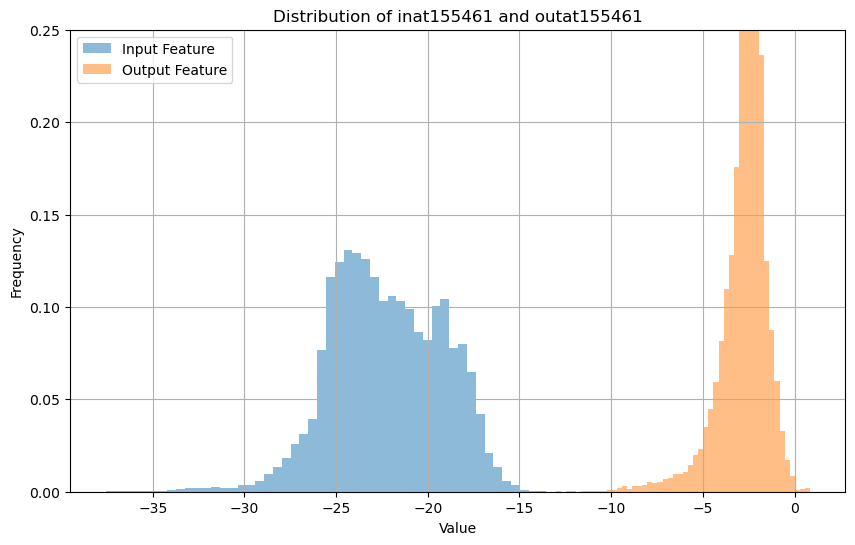

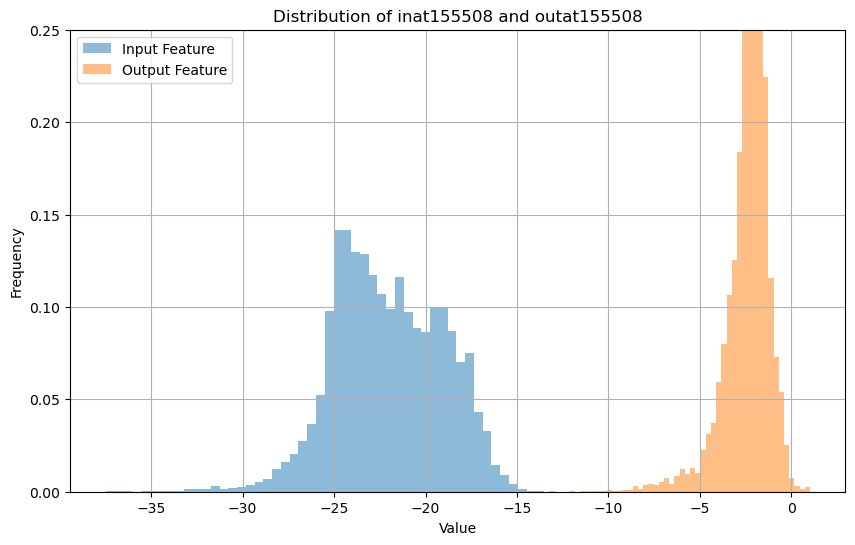

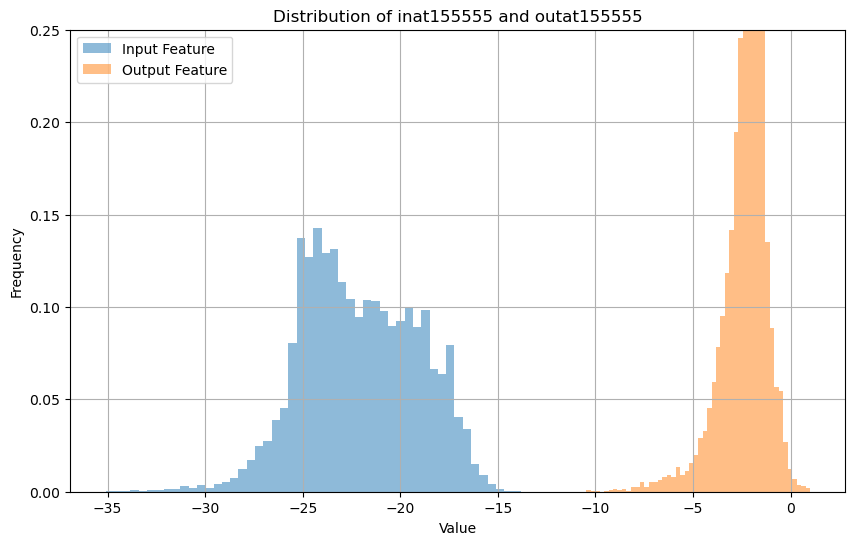

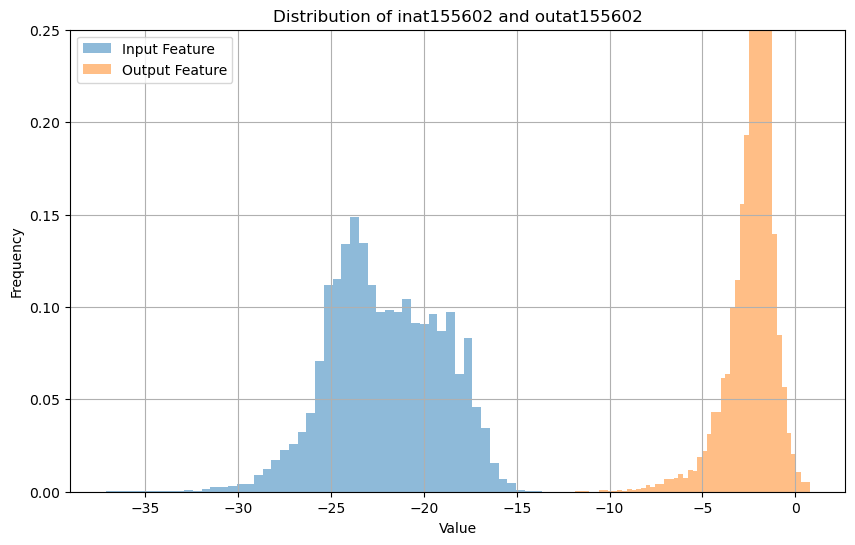

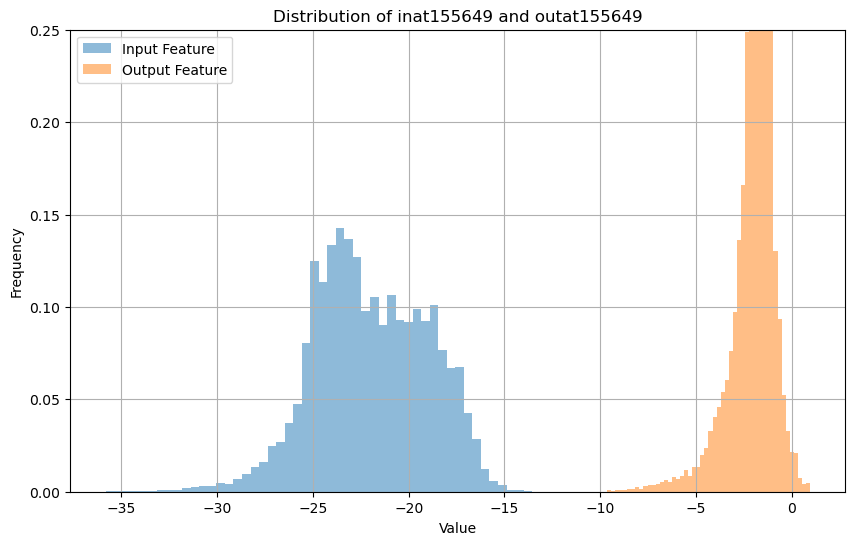

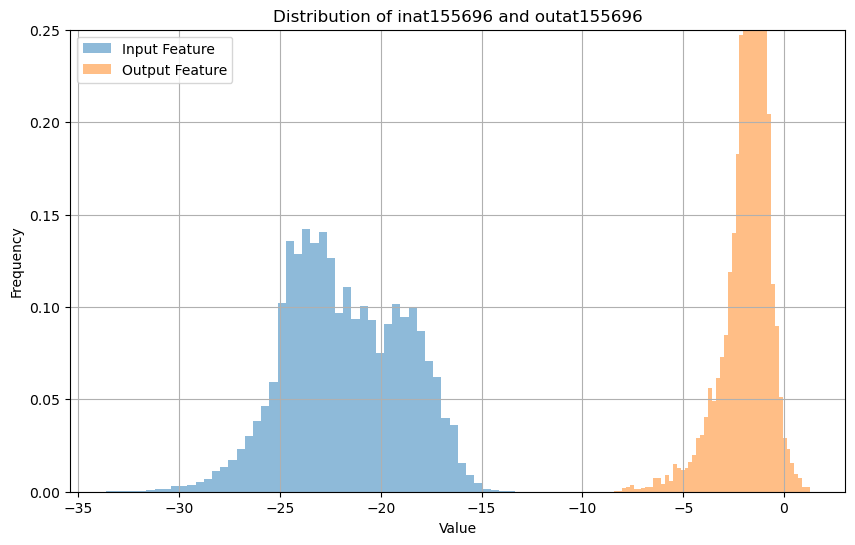

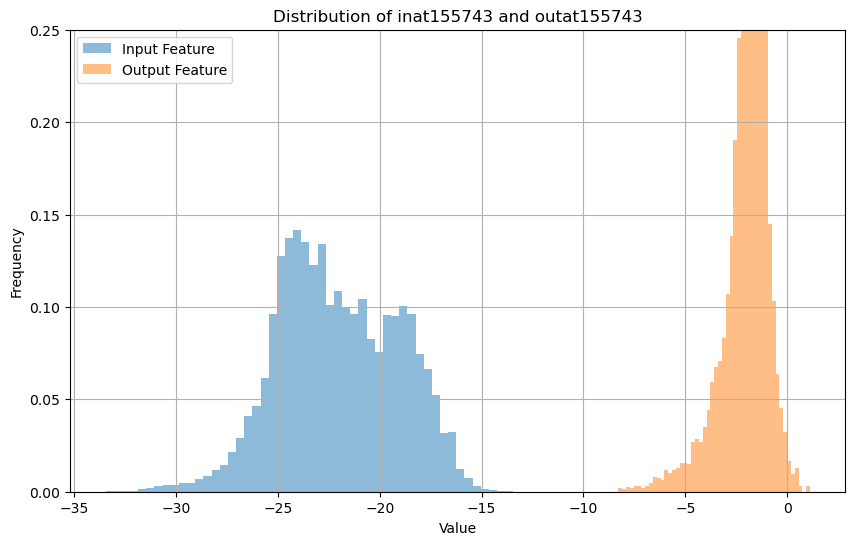

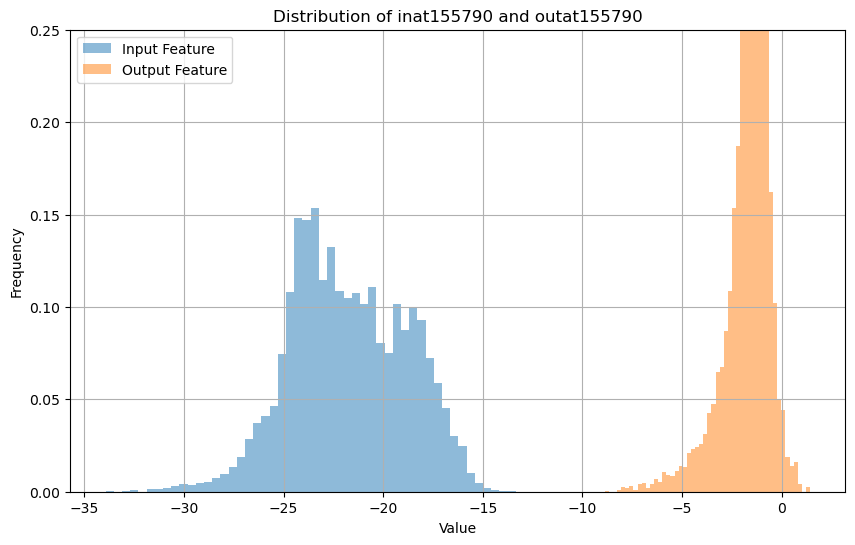

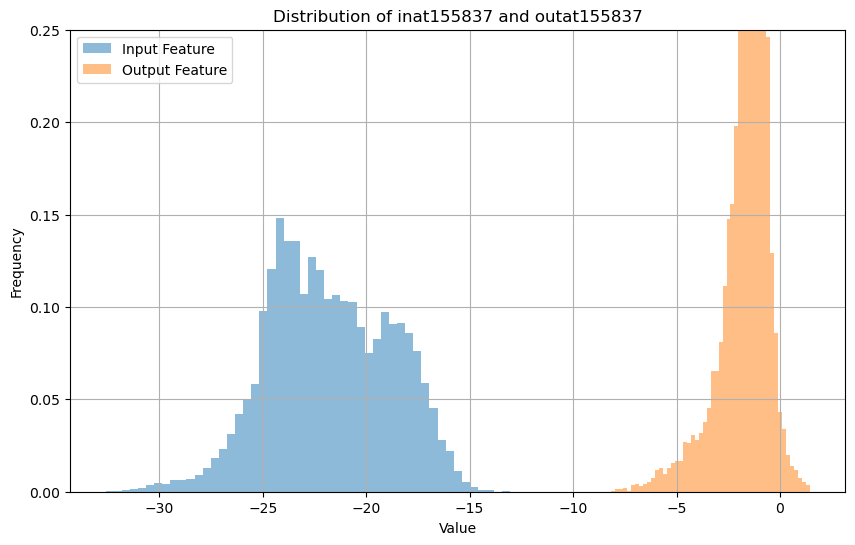

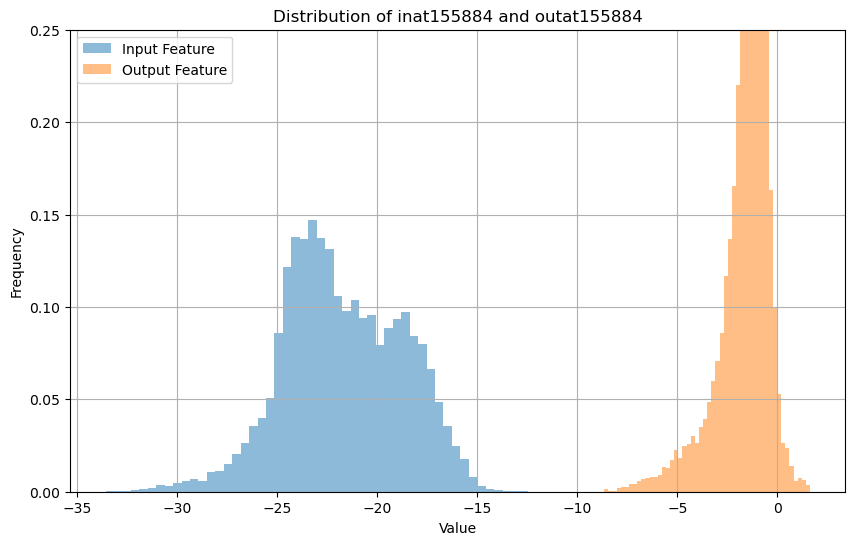

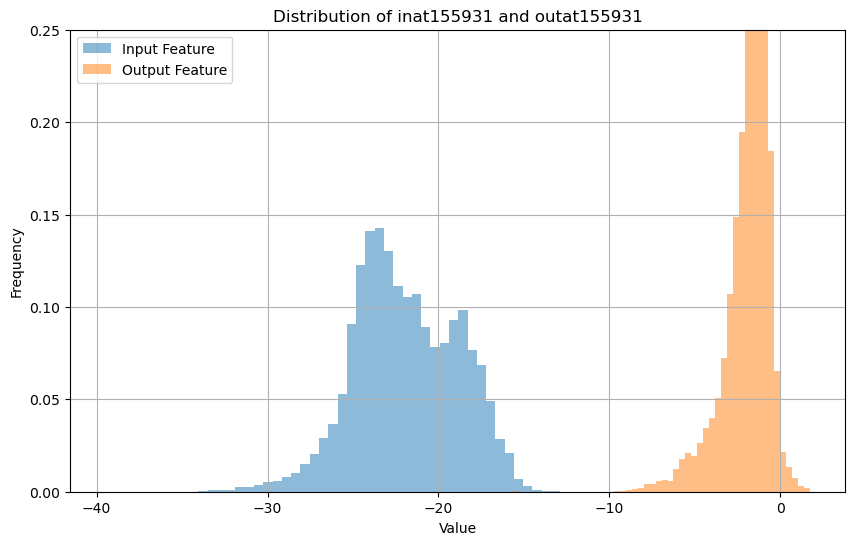

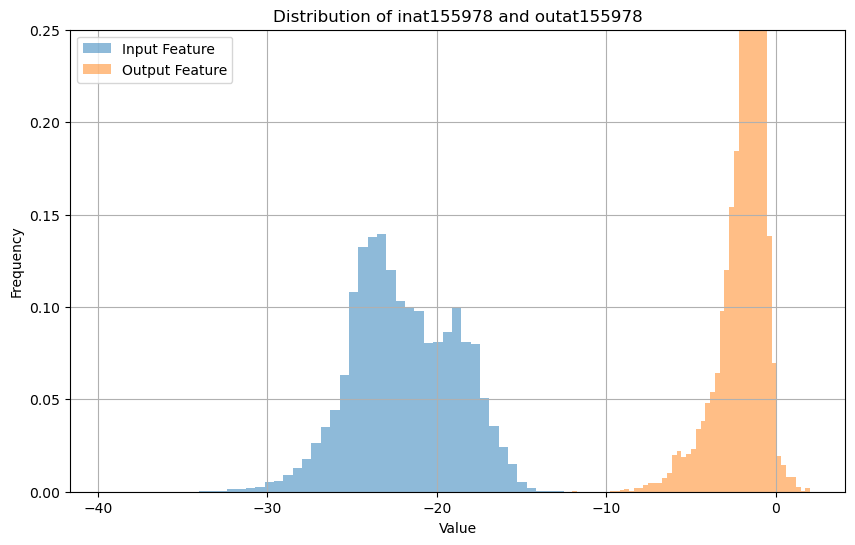

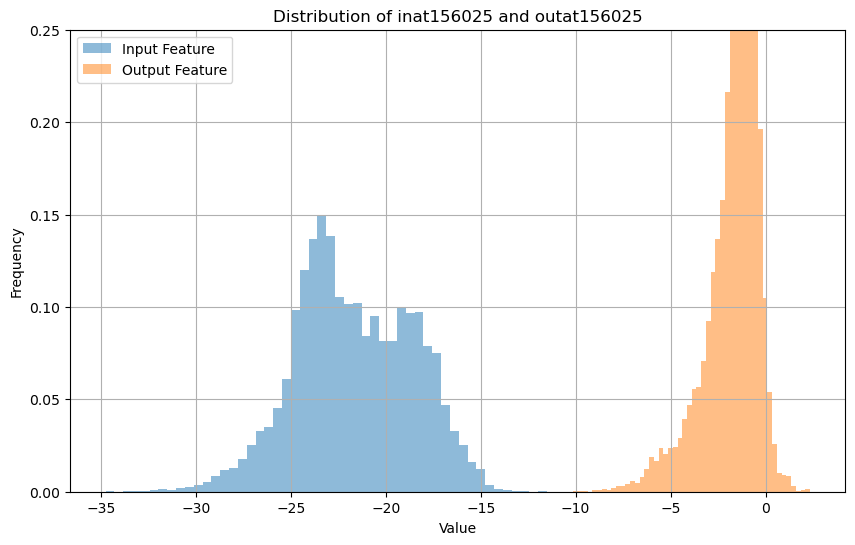

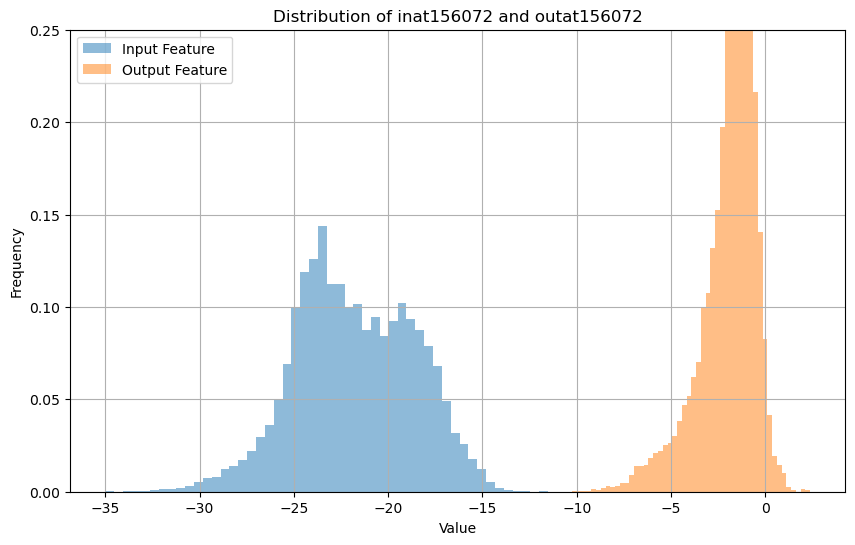

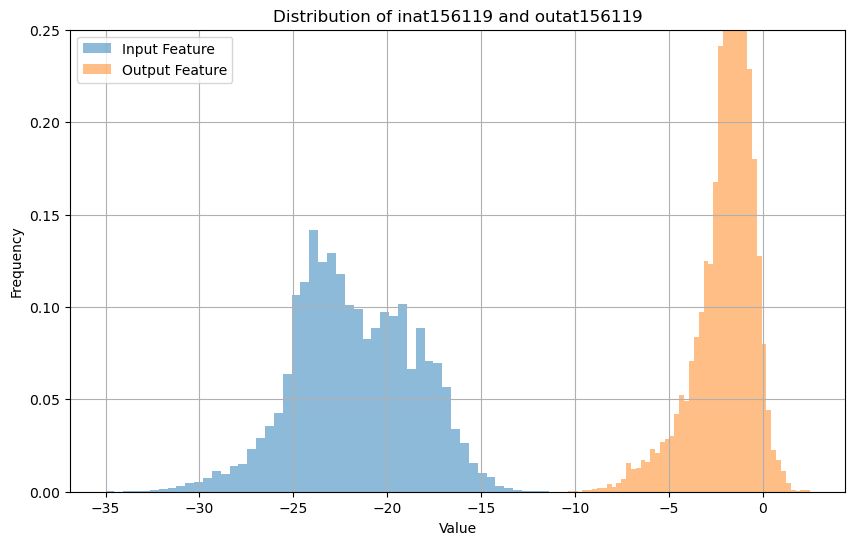

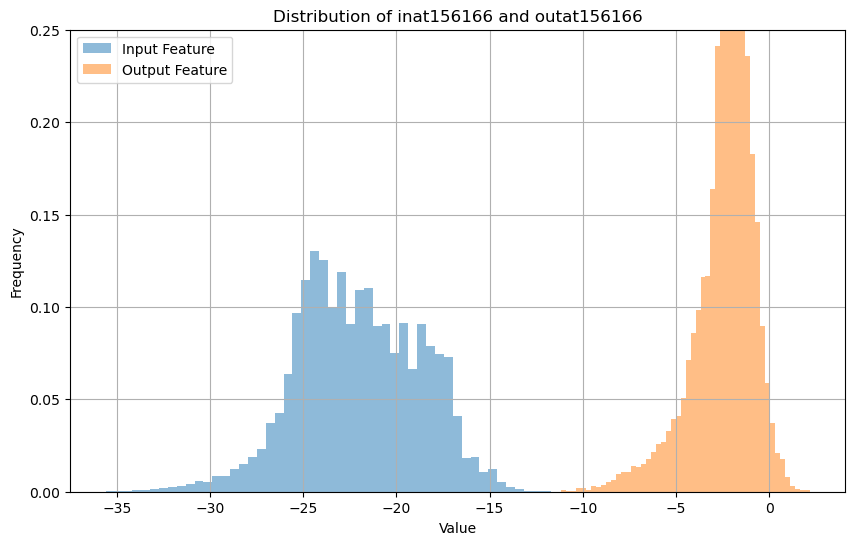

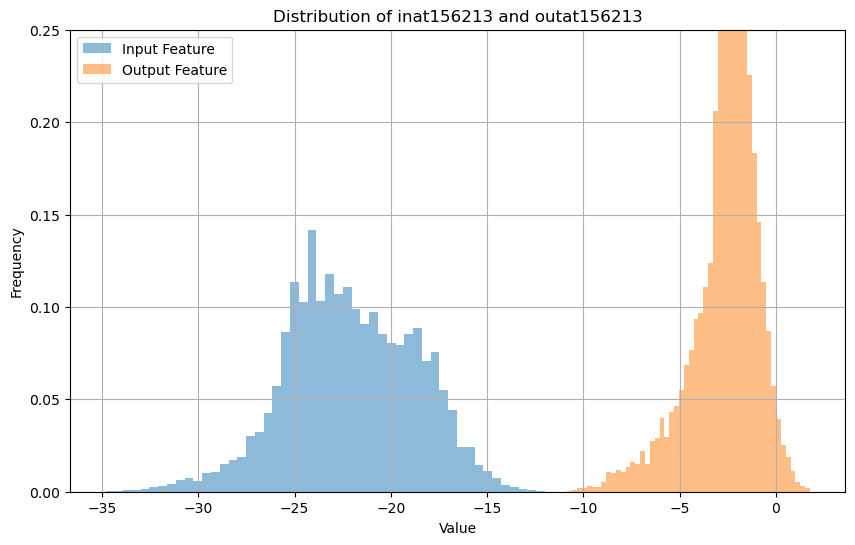

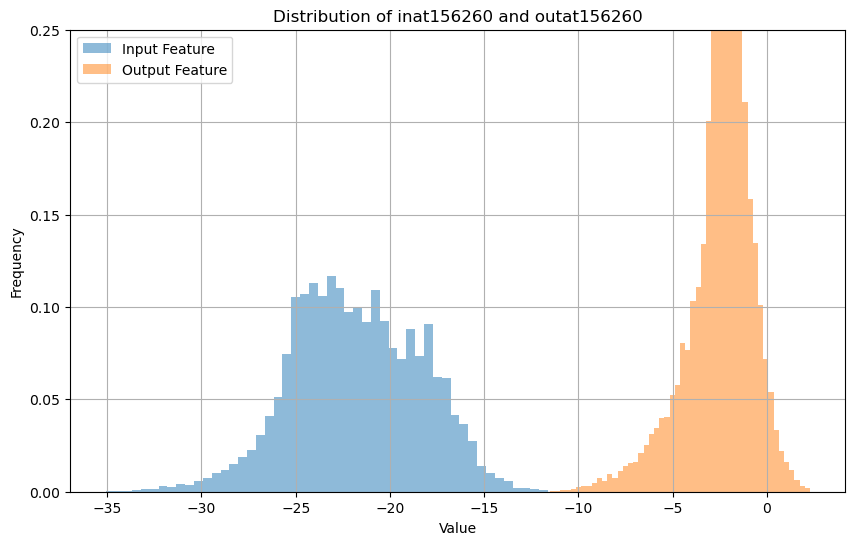

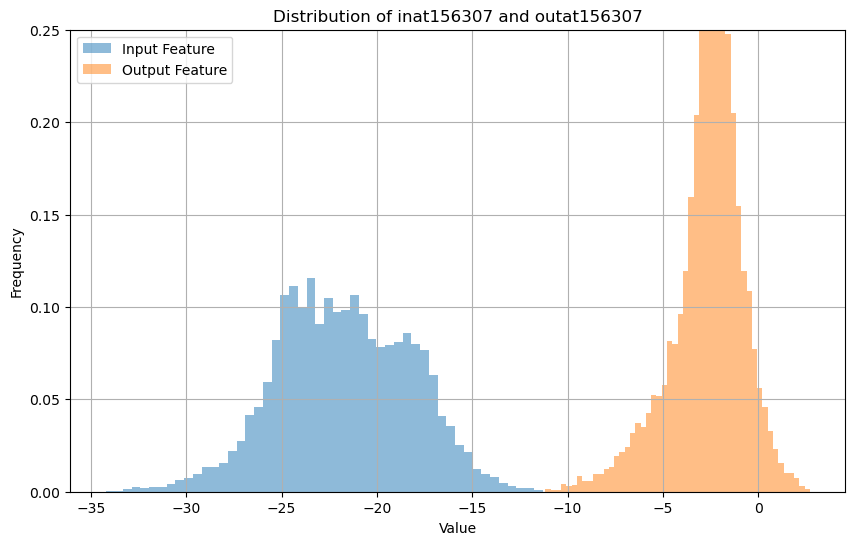

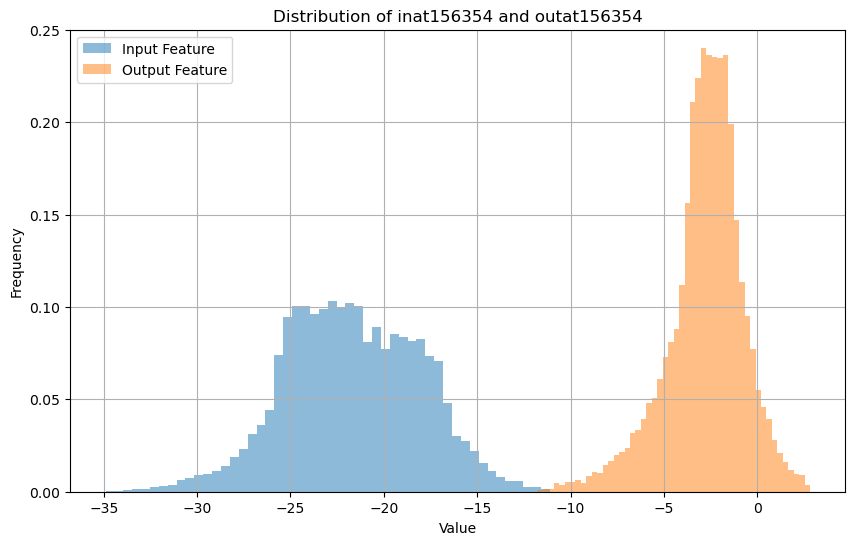

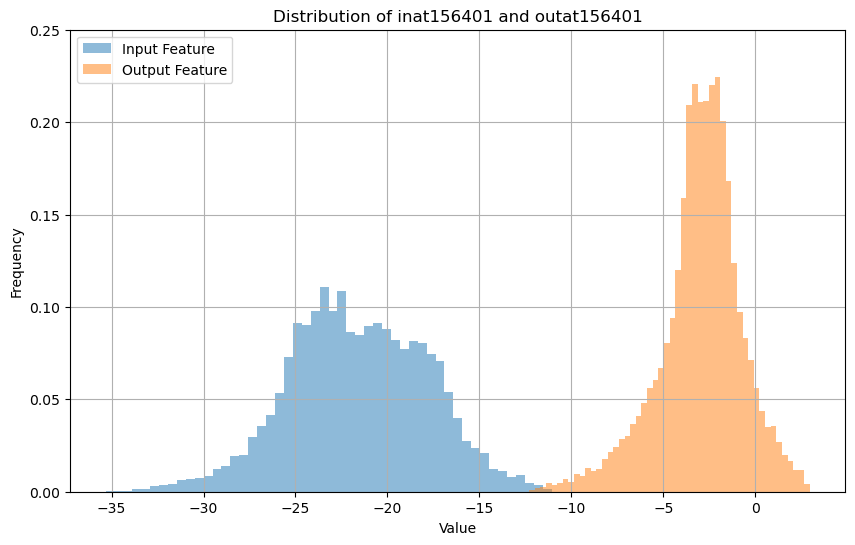

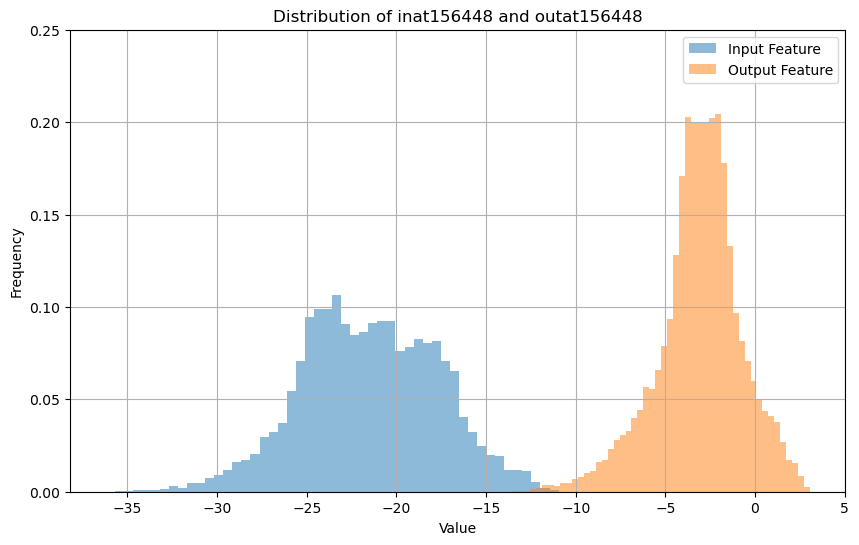

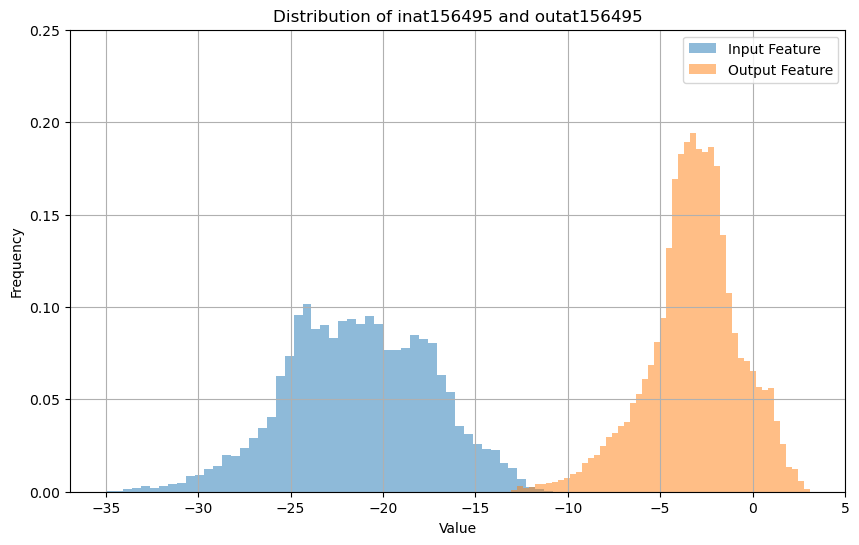

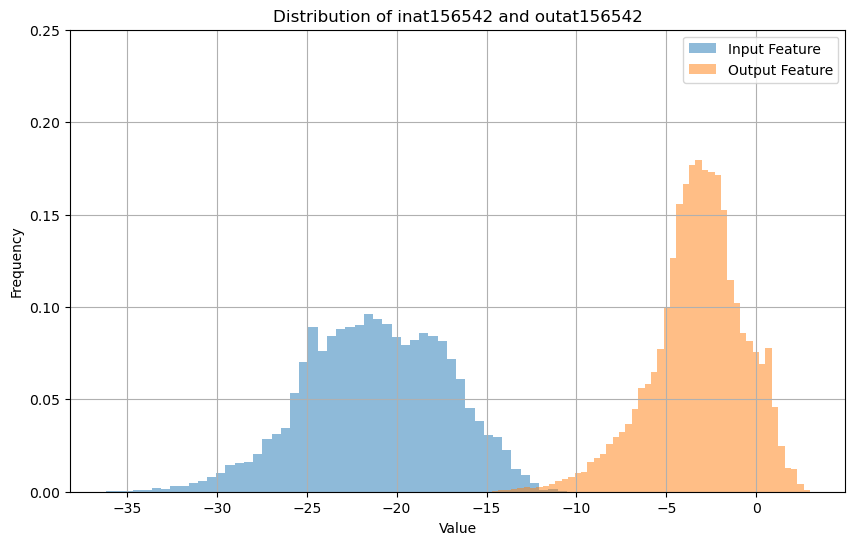

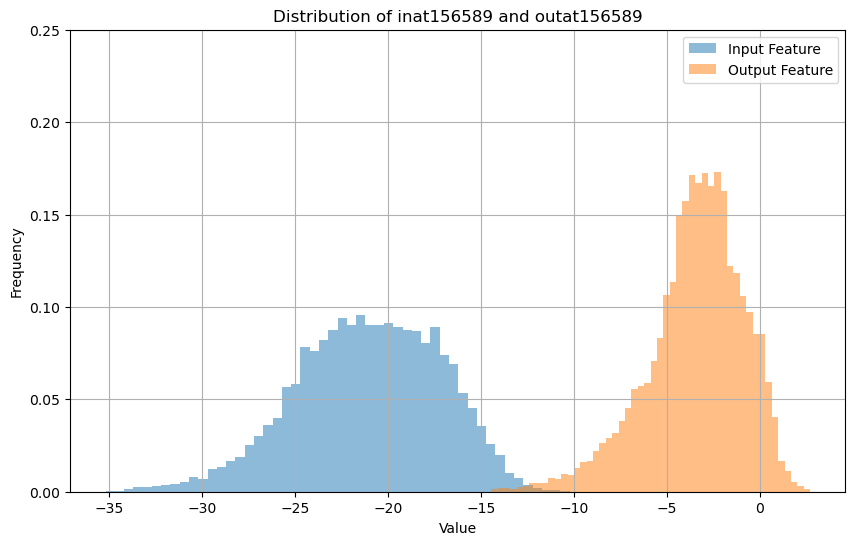

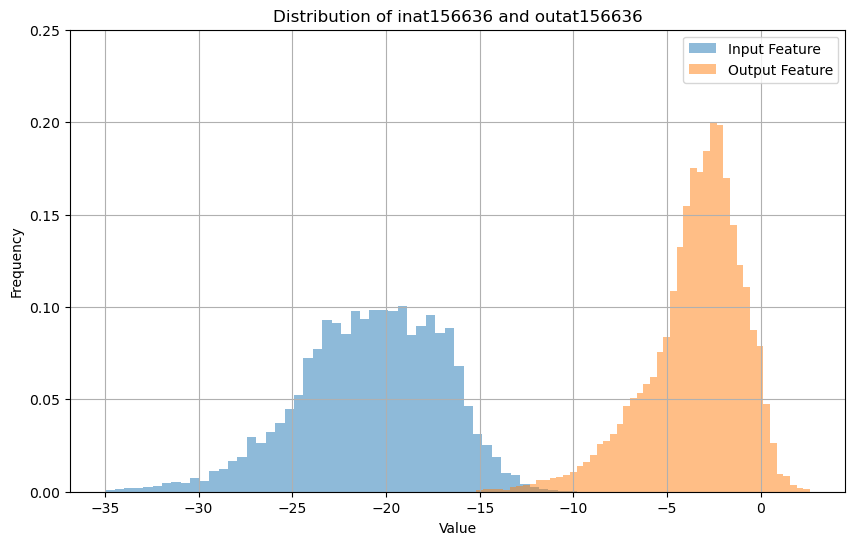

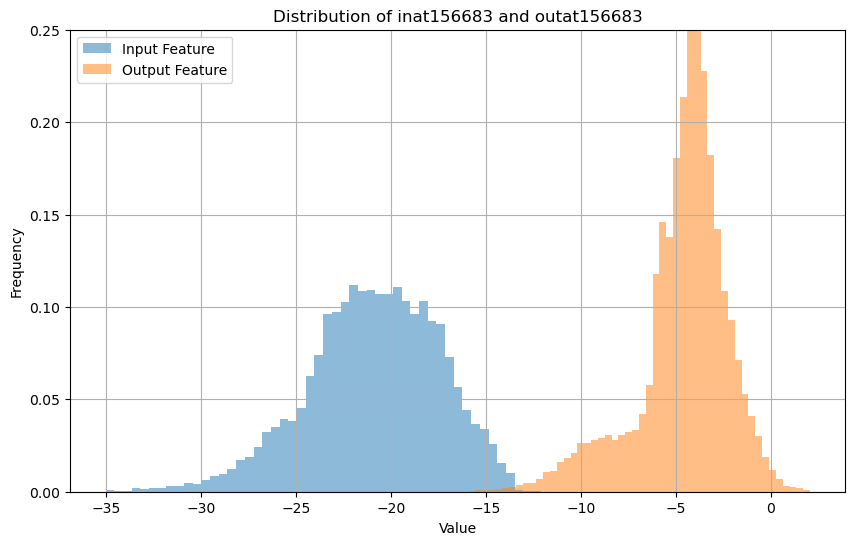

In [ ]:
# Data visualization: Plot the distribution of input and output featuresX_temp, freq_chan = extract_features(raw_data, one_every=1)
X = X_temp[X_temp.columns[2:2+freq_chan]]
y = X_temp[X_temp.columns[-84:]]

# for each column in X, plot the distribution of values (normalized values on y axis)
for colX, colY in zip(X.columns, y.columns):
    plt.figure(figsize=(10, 6))
    plt.hist(X[colX], bins=50, density=True, alpha=0.5, label='Input Feature')
    plt.hist(y[colY], bins=50, density=True, alpha=0.5, label='Output Feature')
    plt.title(f'Distribution of {colX} and {colY}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.ylim(0, 0.25)
    plt.legend()
    plt.grid()
    #plt.show()
    #save the figure
    plt.savefig(f'distributions/{colX}_vs_{colY}.png')